<a href="https://colab.research.google.com/github/Ali-datasmith/data-science-foundations/blob/main/pandas/pandas_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#`🐼 Pandas for Data Science — Complete Reference Notebook`

**Author:** Muhammad Ali Rajput<br>
**Last Updated:** March 2026  
**Tools:** Python 3.12.13 | Pandas | NumPy  

---

This notebook covers **Pandas from the ground up**, built through hands-on learning and structured practice. Every chapter includes concept explanations, working code examples, and a dedicated practice set.

> 💡 Best viewed in **Jupyter Notebook** or **Google Colab**<br>
> `NOTE` : The Questions in practice sets are AI generated

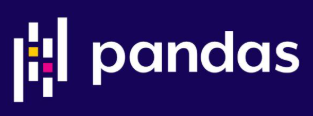

## 📋 Table of Contents

| # | Chapter | Key Topics |
|---|---------|------------|
| 1 | Introduction to Pandas | Installation, import, version, first DataFrame |
| 2 | DataFrame Basics | head, tail, shape, columns, info, describe, rename |
| 3 | Saving & Loading Data | to_csv, read_csv, read_excel, Google Colab Drive |
| 4 | Rows & Columns Selection | loc, iloc, boolean masking, where() |
| 5 | Add, Update & Delete | Adding/updating rows & cols, drop(), sort_values() |
| 6 | Working with Dates | to_datetime, .dt accessor, Timedelta |
| 7 | Handling Missing Values | isnull, fillna, dropna, ffill, bfill |
| 8 | GroupBy & Aggregation | groupby, agg, transform, filter, apply |
| 9 | Concat & Merge | pd.concat, pd.merge, join types |
| 10 | AI-Assisted Coding | Using AI prompts + query() method |
| 11 | Handling Duplicates | duplicated, drop_duplicates |
| 12 | Reshape: Pivot & Melt | melt, pivot, pivot_table, margins |




---
## 📌 Chapter 1 — Introduction to Pandas

Pandas is the most widely used Python library for data manipulation and analysis. It provides two main data structures: **Series** (1D) and **DataFrame** (2D table). We start by importing the library and confirming the version.

### Importing the Libraries

By convention, pandas is imported as `pd` and numpy as `np`. Both are imported **once here** and available throughout the entire notebook.

In [ ]:
import numpy as np
import pandas as pd
#To suppress future warnings
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

Checking the version

In [ ]:
print(f"Pandas Version : {pd.__version__}")
print(f"Numpy Version : {np.__version__}")

Pandas Version : 2.2.2
Numpy Version : 2.0.2


### Creating Your First DataFrame

In [ ]:
#1.Create DataFrame :
df = pd.DataFrame([11,22,33])
print(df)

    0
0  11
1  22
2  33


### Adding Column Name

In [ ]:
# adding column name in the dataframe
df = pd.DataFrame([11,22,33],columns=['Numbers'])
print(df)

   Numbers
0       11
1       22
2       33


###Checking the type using type(value) functions

In [ ]:
#Using type() function to check the type
print(type(df))

<class 'pandas.core.frame.DataFrame'>


###Creating DataFrame from dictionary

In [ ]:
#Dictionary to DataFrame
data = {
    'Name':['Ali','Ahmed','Ahsan','Laiba'],
    'Age':[20,21,20,21],
    'Salary':[100000,90000,80000,95000]
}
df = pd.DataFrame(data)

In [ ]:
# Quick note on display:
# print(df)  → plain text output, good for scripts
# df         → rich HTML table, best inside a notebook
print(df)

    Name  Age  Salary
0    Ali   20  100000
1  Ahmed   21   90000
2  Ahsan   20   80000
3  Laiba   21   95000


In [ ]:
# Displaying as a formatted table (notebook-style)
df

,Name,Age,Salary
0,Ali,20,100000
1,Ahmed,21,90000
2,Ahsan,20,80000
3,Laiba,21,95000


In [ ]:
#Checking the type again
print(type(df))

<class 'pandas.core.frame.DataFrame'>


---
## 📌 Chapter 2 — : DataFrame Basics


### `head()` and `tail()` — Preview the Data

- `df.head(n)` → first **n** rows (default 5)
- `df.tail(n)` → last  **n** rows (default 5)

# First 5 rows (default)
df.head()

In [ ]:
df.head() #by default it gives top 5 rows but we can also view top rows according to our need by putting value in df.head(value)...

,Name,Age,Salary
0,Ali,20,100000
1,Ahmed,21,90000
2,Ahsan,20,80000
3,Laiba,21,95000


In [ ]:
df.head(2)

,Name,Age,Salary
0,Ali,20,100000
1,Ahmed,21,90000


# Last 5 rows (default)
df.tail()

In [ ]:
df.tail() #by default it gives last 5 rows but we can also view last rows according to our need by putting value in df.tail(value)...

,Name,Age,Salary
0,Ali,20,100000
1,Ahmed,21,90000
2,Ahsan,20,80000
3,Laiba,21,95000


In [ ]:
df.tail(2)

,Name,Age,Salary
2,Ahsan,20,80000
3,Laiba,21,95000


### `shape` and `columns` — Understand the Structure

- `df.shape`   → `(rows, columns)` as a tuple — it is a **property**, not a method, so no `()`
- `df.columns` → list of all column names


In [ ]:
#df.shape provides us the total number of rows and columns in a dataframe...
df.shape

(4, 3)

In [ ]:
#df.columns provides us the total number of columns availible in the dataframe
df.columns

Index(['Name', 'Age', 'Salary'], dtype='object')

### `rename()` — Rename Columns

Pass a dictionary `{old_name: new_name}` to `columns=`. Use `inplace=True` to apply the change directly to the original DataFrame.

In [ ]:
#if you want to update same variable use inplace=True or use another variable like df1 to store above value...
df.rename(columns={'Salary':'Monthly_Salary'},inplace=True)
df

,Name,Age,Monthly_Salary
0,Ali,20,100000
1,Ahmed,21,90000
2,Ahsan,20,80000
3,Laiba,21,95000


### `info()` — Column Types and Null Counts

`df.info()` is the fastest way to spot missing values and wrong data types before any analysis.

In [ ]:
df.info()
# provides basic level details about dataframe...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            4 non-null      object
 1   Age             4 non-null      int64 
 2   Monthly_Salary  4 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 228.0+ bytes


### `describe()` — Statistical Summary

Returns count, mean, std, min, 25th / 50th / 75th percentile, and max for all numeric columns.

In [ ]:
df.describe()

,Age,Monthly_Salary
count,4.00000,4.000000
mean,20.50000,91250.000000
std,0.57735,8539.125638
min,20.00000,80000.000000
25%,20.00000,87500.000000
50%,20.50000,92500.000000
75%,21.00000,96250.000000
max,21.00000,100000.000000


---
## 📌 Chapter 3 — : Exporting and Importing Dataset in GoogleColab using Drive

### Exporting a DataFrame

- `df.to_csv('file.csv', index=False)` — saves as CSV without the row index
- `df.to_excel('file.xlsx', index=False)` — saves as Excel<br>
You can also convert to other formats like json etc

In [ ]:
#Export dataframe
df.to_csv('Test_Data.csv',index=False)
print("File saved as Test_Data.csv successfully")

File saved as Test_Data.csv successfully


### Loading Data — Google Colab with Google Drive

If you are running this on **Google Colab**, you can mount your Drive to access files stored there. The block below is commented out — uncomment it only when running in Colab.

In [ ]:
# # For importing a dataset do this ...
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# !ls '/content/drive/MyDrive'

In [ ]:
# file_path = '/content/drive/MyDrive/Test_Data.xlsx'
# df = pd.read_excel(file_path)
# df

---
## 📌 Chapter 4 — Rows & Columns Selection

Selecting the right rows and columns is the most frequent operation in data work. Pandas gives you three main tools: **direct column access**, **`.loc[]`** (label-based), and **`.iloc[]`** (position-based).

In [ ]:
# Working dataset for this chapter
data = {
    'Name'          : ['Ali', 'Ahmed', 'Ahsan', 'Laiba'],
    'Age'           : [20, 21, 20, 21],
    'Monthly_Salary': [100000, 90000, 80000, 95000]
}
df = pd.DataFrame(data)
df

,Name,Age,Monthly_Salary
0,Ali,20,100000
1,Ahmed,21,90000
2,Ahsan,20,80000
3,Laiba,21,95000


### Selecting Columns

Use **double brackets** `df[['col']]` to return a DataFrame. Single brackets `df['col']` return a Series.

In [ ]:
df[['Name']] #single column

,Name
0,Ali
1,Ahmed
2,Ahsan
3,Laiba


In [ ]:
df[['Name','Monthly_Salary']] #Double column

,Name,Monthly_Salary
0,Ali,100000
1,Ahmed,90000
2,Ahsan,80000
3,Laiba,95000


### `.loc[]` — Label-Based Selection

`.loc[]` uses **index labels and column names**. Key difference from `.iloc[]`: the **stop index is inclusive** in `.loc[]`.

In [ ]:
#loc -> index-label-based
df.loc[df.Name=='Ahsan']

,Name,Age,Monthly_Salary
2,Ahsan,20,80000


In [ ]:
#Select rows based on multiple conditions
df.loc[(df.Name=='Ali') & (df.Monthly_Salary>=50000)]

,Name,Age,Monthly_Salary
0,Ali,20,100000


### `.iloc[]` — Position-Based Selection

`.iloc[]` uses **integer positions** (0-indexed). The stop index is **exclusive** — `iloc[0:2]` returns rows 0 and 1 only.

In [ ]:
#iloc -> index-value-based
df.iloc[0]

,0
Name,Ali
Age,20
Monthly_Salary,100000


In [ ]:
#iloc[start:stop:step]
df.iloc[0:3:2]

,Name,Age,Monthly_Salary
0,Ali,20,100000
2,Ahsan,20,80000


In [ ]:
#Returns the rows from 0 to 1 except 2
df.loc[0:2]

,Name,Age,Monthly_Salary
0,Ali,20,100000
1,Ahmed,21,90000
2,Ahsan,20,80000


In [ ]:
# Side-by-side comparison — loc vs iloc on the same range
print('loc[0:2]  → includes row 2 (INCLUSIVE stop)')
print(df.loc[0:2])
print()
print('iloc[0:2] → excludes row 2 (EXCLUSIVE stop)')
print(df.iloc[0:2])

loc[0:2]  → includes row 2 (INCLUSIVE stop)
    Name  Age  Monthly_Salary
0    Ali   20          100000
1  Ahmed   21           90000
2  Ahsan   20           80000

iloc[0:2] → excludes row 2 (EXCLUSIVE stop)
    Name  Age  Monthly_Salary
0    Ali   20          100000
1  Ahmed   21           90000


### Boolean Masking and `.where()`

**Boolean masking** returns only the rows that match the condition.

**`.where()`** keeps the full DataFrame shape but replaces non-matching rows with `NaN` (or a custom value).

In [ ]:
# Returns a True/False value for each row
df['Age']>20

,Age
0,False
1,True
2,False
3,True


In [ ]:
#Returns the rows where Age is greater than 20
df[df['Age']>20]

,Name,Age,Monthly_Salary
1,Ahmed,21,90000
3,Laiba,21,95000


In [ ]:
# Save the result in a variable
df_age_filter = df[df['Age']>20]
df_age_filter

,Name,Age,Monthly_Salary
1,Ahmed,21,90000
3,Laiba,21,95000


In [ ]:
#Multiple conditions filtering
df[(df['Age']>20) & (df['Monthly_Salary']>90000)]

,Name,Age,Monthly_Salary
3,Laiba,21,95000


In [ ]:
#Returns the values which matched the condition and repalces others with NaN
df.where(df['Age']>20)

,Name,Age,Monthly_Salary
0,NaN,NaN,NaN
1,Ahmed,21.0,90000.0
2,NaN,NaN,NaN
3,Laiba,21.0,95000.0


In [ ]:
#Returns the values which matched the condition and repalces others with 'Not Eligible'
df.where(df['Age']>20,other='Not Eligible')

,Name,Age,Monthly_Salary
0,Not Eligible,Not Eligible,Not Eligible
1,Ahmed,21,90000
2,Not Eligible,Not Eligible,Not Eligible
3,Laiba,21,95000


---
### 🧪 Practice Set — Chapters 1 to 4

Work through the levels below using the student dataset.

In [ ]:
# Practice dataset
data = {
    'Name'  : ['Ali', 'Ahmed', 'Aina', 'Narmeen', 'Ayesha', 'Saad'],
    'Age'   : [18, 17, 16, 19, 20, 20],
    'Gender': ['Male', 'Male', 'Female', 'Female', 'Female', 'Male'],
    'Marks' : [98, 89, 90, 91, 96, 85],
    'City'  : ['Karachi', 'Lahore', 'Karachi', 'Lahore', 'Islamabad', 'Islamabad']
}
df = pd.DataFrame(data)
df

,Name,Age,Gender,Marks,City
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


#### 🟢 Level 1 — Basics

1. Find the number of rows and columns
2. Display only the column names
3. Show a summary of non-null values for each column
4. Generate a statistical summary of numeric columns
5. Display complete DataFrame information (data types, nulls, memory)

In [ ]:
df.shape

(6, 5)

In [ ]:
df.columns

Index(['Name', 'Age', 'Gender', 'Marks', 'City'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    6 non-null      object
 1   Age     6 non-null      int64 
 2   Gender  6 non-null      object
 3   Marks   6 non-null      int64 
 4   City    6 non-null      object
dtypes: int64(2), object(3)
memory usage: 372.0+ bytes


In [ ]:
df.describe()

,Age,Marks
count,6.000000,6.000000
mean,18.333333,91.500000
std,1.632993,4.764452
min,16.000000,85.000000
25%,17.250000,89.250000
50%,18.500000,90.500000
75%,19.750000,94.750000
max,20.000000,98.000000


In [ ]:
df

,Name,Age,Gender,Marks,City
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


#### 🟡 Level 2 — loc & iloc

1. Select the first 5 rows using `iloc`
2. Select only the **Name** and **Marks** columns
3. Extract rows from index 2 to index 5 using `loc`
4. Retrieve the complete row at index 3
5. Select the last 2 rows using `iloc`

In [ ]:
df.iloc[:5]

,Name,Age,Gender,Marks,City
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad


In [ ]:
df[['Name','Marks']]

,Name,Marks
0,Ali,98
1,Ahmed,89
2,Aina,90
3,Narmeen,91
4,Ayesha,96
5,Saad,85


In [ ]:
df.loc[2:5]

,Name,Age,Gender,Marks,City
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


In [ ]:
df.iloc[3]

,3
Name,Narmeen
Age,19
Gender,Female
Marks,91
City,Lahore


In [ ]:
df.iloc[-2:]
#or
# df.tail(2)

,Name,Age,Gender,Marks,City
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


#### 🟠 Level 3 — where()

1. Show data where Marks > 90
2. Replace values with NaN where Age < 18
3. Keep rows where City is **Karachi**, replace others with NaN
4. Keep data where Marks ≥ 50, replace the rest with NaN

In [ ]:
df.where(df['Marks']>90,other='Not ELigible')

,Name,Age,Gender,Marks,City
0,Ali,18,Male,98,Karachi
1,Not ELigible,Not ELigible,Not ELigible,Not ELigible,Not ELigible
2,Not ELigible,Not ELigible,Not ELigible,Not ELigible,Not ELigible
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Not ELigible,Not ELigible,Not ELigible,Not ELigible,Not ELigible


In [ ]:
df.where(df['Age']>=18)

,Name,Age,Gender,Marks,City
0,Ali,18.0,Male,98.0,Karachi
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,Narmeen,19.0,Female,91.0,Lahore
4,Ayesha,20.0,Female,96.0,Islamabad
5,Saad,20.0,Male,85.0,Islamabad


In [ ]:
df.where(df['City']=='Karachi')

,Name,Age,Gender,Marks,City
0,Ali,18.0,Male,98.0,Karachi
1,NaN,NaN,NaN,NaN,NaN
2,Aina,16.0,Female,90.0,Karachi
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.where(df['Marks']>=50)

,Name,Age,Gender,Marks,City
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


#### 🔵 Level 4 — rename()

1. Rename **Marks** to **Total_Marks**
2. Rename **Age** to **Student_Age** and **City** to **Location**
3. Display the updated column list

In [ ]:
df1 = df.rename(columns={'Marks':'Total_Marks'})
df1

,Name,Age,Gender,Total_Marks,City
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


In [ ]:
df1.rename(columns={'Age':'Student_Age','City':'Location'},inplace=True)
df1

,Name,Student_Age,Gender,Total_Marks,Location
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


#### 🔴 Mixed Practice (Exam-Style)

1. Determine how many numeric columns are present
2. Find the average Marks using the statistical summary
3. Display only names of students who scored more than 80
4. Find total number of students using `df.shape`
5. Select only the **Gender** column using `loc`

In [ ]:
df.describe(include=[np.number])
#or simply df.describe() ->default numeric columns only...

,Age,Marks
count,6.000000,6.000000
mean,18.333333,91.500000
std,1.632993,4.764452
min,16.000000,85.000000
25%,17.250000,89.250000
50%,18.500000,90.500000
75%,19.750000,94.750000
max,20.000000,98.000000


In [ ]:
df.describe().loc['mean', 'Marks']

np.float64(91.5)

In [ ]:
df.where(df['Marks']>80,other='Not Eligible')

,Name,Age,Gender,Marks,City
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


In [ ]:
df.shape[0]

6

In [ ]:
df.loc[:,'Gender']
 #or use simply df[['Gender]] without the need of df.loc[]

,Gender
0,Male
1,Male
2,Female
3,Female
4,Female
5,Male


✅ Practice Set Chapters 1–4 — Complete

---
## 📌 Chapter 5 — Add, Update & Delete Operations

Real datasets are never static. You will constantly be adding new columns, correcting values, removing rows, and sorting data.

### Adding Rows and Columns

In [ ]:
# Fresh dataset for this chapter
data = {
    'Name'  : ['Ali', 'Ahmed', 'Ahsan', 'Laiba'],
    'Age'   : [20, 21, 20, 21],
    'Salary': [100000, 90000, 80000, 95000]
}
df = pd.DataFrame(data)
df

,Name,Age,Salary
0,Ali,20,100000
1,Ahmed,21,90000
2,Ahsan,20,80000
3,Laiba,21,95000


In [ ]:
# add new column directly
df['Team'] = ['HR','DA','CEO','CFO']
df

,Name,Age,Salary,Team
0,Ali,20,100000,HR
1,Ahmed,21,90000,DA
2,Ahsan,20,80000,CEO
3,Laiba,21,95000,CFO


In [ ]:
#adding column based on calculations
df['Bonus'] = df['Salary'] * 20/100
df

,Name,Age,Salary,Team,Bonus
0,Ali,20,100000,HR,20000.0
1,Ahmed,21,90000,DA,18000.0
2,Ahsan,20,80000,CEO,16000.0
3,Laiba,21,95000,CFO,19000.0


In [ ]:
# add new row
df.loc[len(df)] = ['Sabrina',22,70000,'IT',70000*20/100]
df

,Name,Age,Salary,Team,Bonus
0,Ali,20,100000,HR,20000.0
1,Ahmed,21,90000,DA,18000.0
2,Ahsan,20,80000,CEO,16000.0
3,Laiba,21,95000,CFO,19000.0
4,Sabrina,22,70000,IT,14000.0


In [ ]:
#length has increased after adding a new row
len(df)

5

### Updating Rows and Columns

In [ ]:
# updating value using index value
df.loc[0,'Salary'] = 98000
df

,Name,Age,Salary,Team,Bonus
0,Ali,20,98000,HR,20000.0
1,Ahmed,21,90000,DA,18000.0
2,Ahsan,20,80000,CEO,16000.0
3,Laiba,21,95000,CFO,19000.0
4,Sabrina,22,70000,IT,14000.0


In [ ]:
#updating laiba's salary
df.loc[df.Name=='Laiba','Salary'] = 87000
df

,Name,Age,Salary,Team,Bonus
0,Ali,20,98000,HR,20000.0
1,Ahmed,21,90000,DA,18000.0
2,Ahsan,20,80000,CEO,16000.0
3,Laiba,21,87000,CFO,19000.0
4,Sabrina,22,70000,IT,14000.0


### Deleting Rows and Columns with `.drop()`

Droping rows

In [ ]:
#drop row -> axis = 0
df.drop(df[df.Name=='Ahsan'].index,inplace=True)
df

,Name,Age,Salary,Team,Bonus
0,Ali,20,98000,HR,20000.0
1,Ahmed,21,90000,DA,18000.0
3,Laiba,21,87000,CFO,19000.0
4,Sabrina,22,70000,IT,14000.0


In [ ]:
#second method using index...
df.drop(0)

,Name,Age,Salary,Team,Bonus
1,Ahmed,21,90000,DA,18000.0
3,Laiba,21,87000,CFO,19000.0
4,Sabrina,22,70000,IT,14000.0


Droping column

In [ ]:
#drop column -> axis = 1
df.drop('Team',axis=1,inplace=True)
df

,Name,Age,Salary,Bonus
0,Ali,20,98000,20000.0
1,Ahmed,21,90000,18000.0
3,Laiba,21,87000,19000.0
4,Sabrina,22,70000,14000.0


In [ ]:
#to delete multiple columns use this
# df.drop(['Bonus','Salary'],axis=1,inplace=True)

In [ ]:
df

,Name,Age,Salary,Bonus
0,Ali,20,98000,20000.0
1,Ahmed,21,90000,18000.0
3,Laiba,21,87000,19000.0
4,Sabrina,22,70000,14000.0


### Sorting the DataFrame

In [ ]:
#sort method ---  default -> ascending order
df.sort_values('Salary')

,Name,Age,Salary,Bonus
4,Sabrina,22,70000,14000.0
3,Laiba,21,87000,19000.0
1,Ahmed,21,90000,18000.0
0,Ali,20,98000,20000.0


In [ ]:
#now it will be in descending order...
df.sort_values('Salary',ascending=False)

,Name,Age,Salary,Bonus
0,Ali,20,98000,20000.0
1,Ahmed,21,90000,18000.0
3,Laiba,21,87000,19000.0
4,Sabrina,22,70000,14000.0


---
### 🧪 Practice Set — Chapter 5

Use the student dataset below to complete all levels.

In [ ]:
# Practice dataset
data = {
    'Name'  : ['Ali', 'Ahmed', 'Aina', 'Narmeen', 'Ayesha', 'Saad'],
    'Age'   : [18, 17, 16, 19, 20, 20],
    'Gender': ['Male', 'Male', 'Female', 'Female', 'Female', 'Male'],
    'Marks' : [98, 89, 90, 91, 96, 85],
    'City'  : ['Karachi', 'Lahore', 'Karachi', 'Lahore', 'Islamabad', 'Islamabad']
}
df = pd.DataFrame(data)
df

,Name,Age,Gender,Marks,City
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,Lahore
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad


#### 🟢 Level 1 — Add Columns

1. Add a **Passed** column: `Marks ≥ 50 → True`, otherwise `False`
2. Add a **Bonus_Marks** column: give 5 marks to every student
3. Add a **Total** column: `Marks + Bonus_Marks`
4. Add a **Country** column with value `'Pakistan'` for all rows

In [ ]:
#here i am doing >=90 because marks are between 80 & 100
df['Passed'] = df['Marks']>=90
df

,Name,Age,Gender,Marks,City,Passed
0,Ali,18,Male,98,Karachi,True
1,Ahmed,17,Male,89,Lahore,False
2,Aina,16,Female,90,Karachi,True
3,Narmeen,19,Female,91,Lahore,True
4,Ayesha,20,Female,96,Islamabad,True
5,Saad,20,Male,85,Islamabad,False


In [ ]:
df['Bonus_Marks'] = 5
df

,Name,Age,Gender,Marks,City,Passed,Bonus_Marks
0,Ali,18,Male,98,Karachi,True,5
1,Ahmed,17,Male,89,Lahore,False,5
2,Aina,16,Female,90,Karachi,True,5
3,Narmeen,19,Female,91,Lahore,True,5
4,Ayesha,20,Female,96,Islamabad,True,5
5,Saad,20,Male,85,Islamabad,False,5


In [ ]:
df['Total'] = df['Marks']+df['Bonus_Marks']
df

,Name,Age,Gender,Marks,City,Passed,Bonus_Marks,Total
0,Ali,18,Male,98,Karachi,True,5,103
1,Ahmed,17,Male,89,Lahore,False,5,94
2,Aina,16,Female,90,Karachi,True,5,95
3,Narmeen,19,Female,91,Lahore,True,5,96
4,Ayesha,20,Female,96,Islamabad,True,5,101
5,Saad,20,Male,85,Islamabad,False,5,90


In [ ]:
df['Country'] = 'Pakistan'
df

,Name,Age,Gender,Marks,City,Passed,Bonus_Marks,Total,Country
0,Ali,18,Male,98,Karachi,True,5,103,Pakistan
1,Ahmed,17,Male,89,Lahore,False,5,94,Pakistan
2,Aina,16,Female,90,Karachi,True,5,95,Pakistan
3,Narmeen,19,Female,91,Lahore,True,5,96,Pakistan
4,Ayesha,20,Female,96,Islamabad,True,5,101,Pakistan
5,Saad,20,Male,85,Islamabad,False,5,90,Pakistan


#### 🟡 Level 2 — Update Values

1. Add 2 marks to students from **Karachi**
2. Replace `'Male'` with `'M'` and `'Female'` with `'F'`
3. Change `'Lahore'` to `'LHR'` in the City column
4. Increase Marks by 10% for students with Marks > 90

In [ ]:
df.loc[df.City=='Karachi','Marks'] = df.loc[df.City=='Karachi','Marks']+2
df

,Name,Age,Gender,Marks,City,Passed,Bonus_Marks,Total,Country
0,Ali,18,Male,100,Karachi,True,5,103,Pakistan
1,Ahmed,17,Male,89,Lahore,False,5,94,Pakistan
2,Aina,16,Female,92,Karachi,True,5,95,Pakistan
3,Narmeen,19,Female,91,Lahore,True,5,96,Pakistan
4,Ayesha,20,Female,96,Islamabad,True,5,101,Pakistan
5,Saad,20,Male,85,Islamabad,False,5,90,Pakistan


In [ ]:
df.loc[df.Gender=='Male','Gender'] = 'M'
df.loc[df.Gender=='Female','Gender'] = 'F'
df

,Name,Age,Gender,Marks,City,Passed,Bonus_Marks,Total,Country
0,Ali,18,M,100,Karachi,True,5,103,Pakistan
1,Ahmed,17,M,89,Lahore,False,5,94,Pakistan
2,Aina,16,F,92,Karachi,True,5,95,Pakistan
3,Narmeen,19,F,91,Lahore,True,5,96,Pakistan
4,Ayesha,20,F,96,Islamabad,True,5,101,Pakistan
5,Saad,20,M,85,Islamabad,False,5,90,Pakistan


In [ ]:
df.loc[df.City=='Lahore','City'] = 'LHR'
df

,Name,Age,Gender,Marks,City,Passed,Bonus_Marks,Total,Country
0,Ali,18,M,100,Karachi,True,5,103,Pakistan
1,Ahmed,17,M,89,LHR,False,5,94,Pakistan
2,Aina,16,F,92,Karachi,True,5,95,Pakistan
3,Narmeen,19,F,91,LHR,True,5,96,Pakistan
4,Ayesha,20,F,96,Islamabad,True,5,101,Pakistan
5,Saad,20,M,85,Islamabad,False,5,90,Pakistan


In [ ]:
df.loc[df.Marks>90,'Marks'] = df.loc[df.Marks>90,'Marks'] * 1.10
df

/tmp/ipykernel_5498/2548491275.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[110.  101.2 100.1 105.6]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df.Marks>90,'Marks'] = df.loc[df.Marks>90,'Marks'] * 1.10


,Name,Age,Gender,Marks,City,Passed,Bonus_Marks,Total,Country
0,Ali,18,M,110.0,Karachi,True,5,103,Pakistan
1,Ahmed,17,M,89.0,LHR,False,5,94,Pakistan
2,Aina,16,F,101.2,Karachi,True,5,95,Pakistan
3,Narmeen,19,F,100.1,LHR,True,5,96,Pakistan
4,Ayesha,20,F,105.6,Islamabad,True,5,101,Pakistan
5,Saad,20,M,85.0,Islamabad,False,5,90,Pakistan


#### 🟠 Level 3 — Drop Columns

1. Drop the **Country** column
2. Drop both **Gender** and **City** at once
3. Create `df2` by dropping **Age** without modifying the original `df`

In [ ]:
df = df.drop('Country',axis=1)
df

,Name,Age,Gender,Marks,City,Passed,Bonus_Marks,Total
0,Ali,18,M,110.0,Karachi,True,5,103
1,Ahmed,17,M,89.0,LHR,False,5,94
2,Aina,16,F,101.2,Karachi,True,5,95
3,Narmeen,19,F,100.1,LHR,True,5,96
4,Ayesha,20,F,105.6,Islamabad,True,5,101
5,Saad,20,M,85.0,Islamabad,False,5,90


In [ ]:
df = df.drop(['Gender','City'],axis=1)
df

,Name,Age,Marks,Passed,Bonus_Marks,Total
0,Ali,18,110.0,True,5,103
1,Ahmed,17,89.0,False,5,94
2,Aina,16,101.2,True,5,95
3,Narmeen,19,100.1,True,5,96
4,Ayesha,20,105.6,True,5,101
5,Saad,20,85.0,False,5,90


In [ ]:
df2 = df.drop('Age',axis=1)
df2

,Name,Marks,Passed,Bonus_Marks,Total
0,Ali,110.0,True,5,103
1,Ahmed,89.0,False,5,94
2,Aina,101.2,True,5,95
3,Narmeen,100.1,True,5,96
4,Ayesha,105.6,True,5,101
5,Saad,85.0,False,5,90


In [ ]:
#orignal df remains the same the change was done in df2
df

,Name,Age,Marks,Passed,Bonus_Marks,Total
0,Ali,18,110.0,True,5,103
1,Ahmed,17,89.0,False,5,94
2,Aina,16,101.2,True,5,95
3,Narmeen,19,100.1,True,5,96
4,Ayesha,20,105.6,True,5,101
5,Saad,20,85.0,False,5,90


#### 🔵 Level 4 — Drop Rows

1. Drop the row at index 2
2. Drop students whose Age is less than 18
3. Remove the last row
4. Reset the index cleanly after all drops

In [ ]:
df = df.drop(2)
df

,Name,Age,Marks,Passed,Bonus_Marks,Total
0,Ali,18,110.0,True,5,103
1,Ahmed,17,89.0,False,5,94
3,Narmeen,19,100.1,True,5,96
4,Ayesha,20,105.6,True,5,101
5,Saad,20,85.0,False,5,90


In [ ]:
df = df.drop(df[df.Age<18].index)
df

,Name,Age,Marks,Passed,Bonus_Marks,Total
0,Ali,18,110.0,True,5,103
3,Narmeen,19,100.1,True,5,96
4,Ayesha,20,105.6,True,5,101
5,Saad,20,85.0,False,5,90


In [ ]:
df = df.drop(df.index[-1])
df

,Name,Age,Marks,Passed,Bonus_Marks,Total
0,Ali,18,110.0,True,5,103
3,Narmeen,19,100.1,True,5,96
4,Ayesha,20,105.6,True,5,101


In [ ]:
df = df.reset_index(drop=True)
df

,Name,Age,Marks,Passed,Bonus_Marks,Total
0,Ali,18,110.0,True,5,103
1,Narmeen,19,100.1,True,5,96
2,Ayesha,20,105.6,True,5,101


#### 🔴 Level 5 — Conditional Columns, Ranking & Combined Filters

Using a larger dataset, practice:

- Adding a **Result** column: `≥90 → Excellent`, `≥70 → Good`, `<70 → Average`
- Adding a **Status** column: `≥50 → Pass`, otherwise `Fail`
- Filtering: `City == Karachi AND Marks > 60`
- Updating marks based on a condition (increase marks of students whose `Age<18`)
- Dropping rows where `Status==Fail AND Result==Average`
- Sort by Marks in descending order
- Reset the index cleanly
-Rank students based on marks

In [ ]:
# Larger dataset for Level 5
data = {
    'Name': ['Ali', 'Ahmed', 'Aina', 'Narmeen', 'Ayesha', 'Saad', 'Zara', 'Hassan', 'Fatima', 'Bilal'],
    'Age': [18, 17, 16, 19, 20, 20, 21, 18, 17, 19],
    'Gender': ['Male', 'Male', 'Female', 'Female', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'Marks': [98, 89, 90, 91, 96, 85, 75, 65, 55, 72],
    'City': ['Karachi', 'Lahore', 'Karachi', 'LHR', 'Islamabad', 'Islamabad', 'Karachi', 'LHR', 'Lahore', 'Karachi']
}
df = pd.DataFrame(data)
df

,Name,Age,Gender,Marks,City
0,Ali,18,Male,98,Karachi
1,Ahmed,17,Male,89,Lahore
2,Aina,16,Female,90,Karachi
3,Narmeen,19,Female,91,LHR
4,Ayesha,20,Female,96,Islamabad
5,Saad,20,Male,85,Islamabad
6,Zara,21,Female,75,Karachi
7,Hassan,18,Male,65,LHR
8,Fatima,17,Female,55,Lahore
9,Bilal,19,Male,72,Karachi


In [ ]:
df['Result'] = 'Null'
df.loc[df.Marks>=90,'Result'] = 'Excellent'
df.loc[df.Marks<90,'Result'] = 'Good'
df.loc[df.Marks<70,'Result'] = 'Average'
df

,Name,Age,Gender,Marks,City,Result
0,Ali,18,Male,98,Karachi,Excellent
1,Ahmed,17,Male,89,Lahore,Good
2,Aina,16,Female,90,Karachi,Excellent
3,Narmeen,19,Female,91,LHR,Excellent
4,Ayesha,20,Female,96,Islamabad,Excellent
5,Saad,20,Male,85,Islamabad,Good
6,Zara,21,Female,75,Karachi,Good
7,Hassan,18,Male,65,LHR,Average
8,Fatima,17,Female,55,Lahore,Average
9,Bilal,19,Male,72,Karachi,Good


In [ ]:
df['Status'] = 'Null'
df.loc[df.Marks>=50,'Status'] = 'Pass'
df.loc[df.Marks<50,'Status'] = 'Fail'
df

,Name,Age,Gender,Marks,City,Result,Status
0,Ali,18,Male,98,Karachi,Excellent,Pass
1,Ahmed,17,Male,89,Lahore,Good,Pass
2,Aina,16,Female,90,Karachi,Excellent,Pass
3,Narmeen,19,Female,91,LHR,Excellent,Pass
4,Ayesha,20,Female,96,Islamabad,Excellent,Pass
5,Saad,20,Male,85,Islamabad,Good,Pass
6,Zara,21,Female,75,Karachi,Good,Pass
7,Hassan,18,Male,65,LHR,Average,Pass
8,Fatima,17,Female,55,Lahore,Average,Pass
9,Bilal,19,Male,72,Karachi,Good,Pass


In [ ]:
df[(df.City=='Karachi') & (df.Marks>60)]

,Name,Age,Gender,Marks,City,Result,Status
0,Ali,18,Male,98,Karachi,Excellent,Pass
2,Aina,16,Female,90,Karachi,Excellent,Pass
6,Zara,21,Female,75,Karachi,Good,Pass
9,Bilal,19,Male,72,Karachi,Good,Pass


In [ ]:
df.loc[df.Age<18,'Marks'] = df.loc[df.Age<18,'Marks']+2
df

,Name,Age,Gender,Marks,City,Result,Status
0,Ali,18,Male,98,Karachi,Excellent,Pass
1,Ahmed,17,Male,91,Lahore,Good,Pass
2,Aina,16,Female,92,Karachi,Excellent,Pass
3,Narmeen,19,Female,91,LHR,Excellent,Pass
4,Ayesha,20,Female,96,Islamabad,Excellent,Pass
5,Saad,20,Male,85,Islamabad,Good,Pass
6,Zara,21,Female,75,Karachi,Good,Pass
7,Hassan,18,Male,65,LHR,Average,Pass
8,Fatima,17,Female,57,Lahore,Average,Pass
9,Bilal,19,Male,72,Karachi,Good,Pass


In [ ]:
df = df.drop(df[(df['Status']=='Fail')&(df['Result']=='Average')].index)
df

,Name,Age,Gender,Marks,City,Result,Status
0,Ali,18,Male,98,Karachi,Excellent,Pass
1,Ahmed,17,Male,91,Lahore,Good,Pass
2,Aina,16,Female,92,Karachi,Excellent,Pass
3,Narmeen,19,Female,91,LHR,Excellent,Pass
4,Ayesha,20,Female,96,Islamabad,Excellent,Pass
5,Saad,20,Male,85,Islamabad,Good,Pass
6,Zara,21,Female,75,Karachi,Good,Pass
7,Hassan,18,Male,65,LHR,Average,Pass
8,Fatima,17,Female,57,Lahore,Average,Pass
9,Bilal,19,Male,72,Karachi,Good,Pass


In [ ]:
df = df.sort_values('Marks',ascending=False)
df

,Name,Age,Gender,Marks,City,Result,Status
0,Ali,18,Male,98,Karachi,Excellent,Pass
4,Ayesha,20,Female,96,Islamabad,Excellent,Pass
2,Aina,16,Female,92,Karachi,Excellent,Pass
1,Ahmed,17,Male,91,Lahore,Good,Pass
3,Narmeen,19,Female,91,LHR,Excellent,Pass
5,Saad,20,Male,85,Islamabad,Good,Pass
6,Zara,21,Female,75,Karachi,Good,Pass
9,Bilal,19,Male,72,Karachi,Good,Pass
7,Hassan,18,Male,65,LHR,Average,Pass
8,Fatima,17,Female,57,Lahore,Average,Pass


In [ ]:
df = df.reset_index(drop=True)
df

,Name,Age,Gender,Marks,City,Result,Status
0,Ali,18,Male,98,Karachi,Excellent,Pass
1,Ayesha,20,Female,96,Islamabad,Excellent,Pass
2,Aina,16,Female,92,Karachi,Excellent,Pass
3,Ahmed,17,Male,91,Lahore,Good,Pass
4,Narmeen,19,Female,91,LHR,Excellent,Pass
5,Saad,20,Male,85,Islamabad,Good,Pass
6,Zara,21,Female,75,Karachi,Good,Pass
7,Bilal,19,Male,72,Karachi,Good,Pass
8,Hassan,18,Male,65,LHR,Average,Pass
9,Fatima,17,Female,57,Lahore,Average,Pass


In [ ]:
# #Method - 1
# df['Rank'] = df.index+1
# df

In [ ]:
#Method - 2
df['Rank'] = df['Marks'].rank(ascending=False,method='dense')
df

,Name,Age,Gender,Marks,City,Result,Status,Rank
0,Ali,18,Male,98,Karachi,Excellent,Pass,1.0
1,Ayesha,20,Female,96,Islamabad,Excellent,Pass,2.0
2,Aina,16,Female,92,Karachi,Excellent,Pass,3.0
3,Ahmed,17,Male,91,Lahore,Good,Pass,4.0
4,Narmeen,19,Female,91,LHR,Excellent,Pass,4.0
5,Saad,20,Male,85,Islamabad,Good,Pass,5.0
6,Zara,21,Female,75,Karachi,Good,Pass,6.0
7,Bilal,19,Male,72,Karachi,Good,Pass,7.0
8,Hassan,18,Male,65,LHR,Average,Pass,8.0
9,Fatima,17,Female,57,Lahore,Average,Pass,9.0


✅ Practice Set Chapter 5 — Complete

---
## 📌 Chapter 6 — Working with Date Values

Dates stored as plain strings are useless for calculations. `pd.to_datetime()` converts them into proper datetime objects, and the `.dt` accessor then unlocks extraction methods like `.dt.year`, `.dt.month_name()`, and `.dt.day_name()`.

In [ ]:
#Working dataset for this chapter
data = {
    'Name':['Ali','Ahmed','Ahsan','Laiba'],
    'Age':[20,21,20,21],
    'Salary':[100000,90000,80000,95000]
}
df = pd.DataFrame(data)
df

,Name,Age,Salary
0,Ali,20,100000
1,Ahmed,21,90000
2,Ahsan,20,80000
3,Laiba,21,95000


In [ ]:
df['DOJ'] = ['2024-01-01','2024-01-15','2024-03-28','2024-03-03']
df

,Name,Age,Salary,DOJ
0,Ali,20,100000,2024-01-01
1,Ahmed,21,90000,2024-01-15
2,Ahsan,20,80000,2024-03-28
3,Laiba,21,95000,2024-03-03


In [ ]:
#now the df['DOJ'] has object datatype...
df['DOJ'].dtype

dtype('O')

In [ ]:
df['DOJ'] = pd.to_datetime(df['DOJ'])

In [ ]:
#converted to datetime datatype...
df['DOJ'].dtype

dtype('<M8[ns]')

### Handling Non-Standard Date Formats

When dates are stored as `DD-MM-YYYY`, you must tell Pandas the format explicitly using `format='%d-%m-%Y'` — otherwise it may misread day and month values.

In [ ]:
df['DOJ2'] = ['01-01-2025','15-01-2025','28-03-2025','03-03-2025']
df

,Name,Age,Salary,DOJ,DOJ2
0,Ali,20,100000,2024-01-01,01-01-2025
1,Ahmed,21,90000,2024-01-15,15-01-2025
2,Ahsan,20,80000,2024-03-28,28-03-2025
3,Laiba,21,95000,2024-03-03,03-03-2025


In [ ]:
df['DOJ2'].dtype

dtype('O')

In [ ]:
df['DOJ2'] = pd.to_datetime(df['DOJ2'],format='%d-%m-%Y')
df

,Name,Age,Salary,DOJ,DOJ2
0,Ali,20,100000,2024-01-01,2025-01-01
1,Ahmed,21,90000,2024-01-15,2025-01-15
2,Ahsan,20,80000,2024-03-28,2025-03-28
3,Laiba,21,95000,2024-03-03,2025-03-03


In [ ]:
df['DOJ2'].dtype

dtype('<M8[ns]')

In [ ]:
df = df.drop('DOJ2',axis=1)
df

,Name,Age,Salary,DOJ
0,Ali,20,100000,2024-01-01
1,Ahmed,21,90000,2024-01-15
2,Ahsan,20,80000,2024-03-28
3,Laiba,21,95000,2024-03-03


### Extracting Date Components with the `.dt` Accessor

Once a column is a proper datetime, `.dt` gives direct access to individual parts.

In [ ]:
# extract year
df['DOJ'].dt.year

,DOJ
0,2024
1,2024
2,2024
3,2024


In [ ]:
#extracts month
df['DOJ'].dt.month

,DOJ
0,1
1,1
2,3
3,3


In [ ]:
#extracts day
df['DOJ'].dt.day

,DOJ
0,1
1,15
2,28
3,3


In [ ]:
#extracts day name
df['DOJ'].dt.day_name()

,DOJ
0,Monday
1,Monday
2,Thursday
3,Sunday


In [ ]:
#making new column named 'Month'
df['Month'] = df['DOJ'].dt.month
df

,Name,Age,Salary,DOJ,Month
0,Ali,20,100000,2024-01-01,1
1,Ahmed,21,90000,2024-01-15,1
2,Ahsan,20,80000,2024-03-28,3
3,Laiba,21,95000,2024-03-03,3


### Adding Time with `pd.Timedelta()`

`pd.Timedelta()` lets you add or subtract a fixed duration from a date column. Useful for calculating deadlines, review periods, or contract end dates.

In [ ]:
df['Promotion_Date'] = df['DOJ'] + pd.Timedelta(days=90)
df

,Name,Age,Salary,DOJ,Month,Promotion_Date
0,Ali,20,100000,2024-01-01,1,2024-03-31
1,Ahmed,21,90000,2024-01-15,1,2024-04-14
2,Ahsan,20,80000,2024-03-28,3,2024-06-26
3,Laiba,21,95000,2024-03-03,3,2024-06-01


---
### 🧪 Practice Set — Chapter 6

#### Datetime Practice Questions

1. Filter all employees who joined in **2024**
2. Filter employees who joined in **March**
3. Filter employees who joined on a **Monday**
4. Create a `Joining_Quarter` column showing Q1–Q4
5. Create a `Tenure_Days` column: days since joining until today
6. Sort by DOJ descending
7. Find the employee who joined **earliest** and the one who joined **latest**
8. Filter employees who joined in January with Salary > 95,000
9. Group by year and count how many joined each year

In [ ]:
#dataset for practice-set
import pandas as pd
data = {
    'Name': ['Ali','Ahmed','Ahsan','Laiba','Sara','Bilal','Nadia','Hassan','Zoya','Usman'],
    'Age': [20,21,20,21,22,23,22,24,21,23],
    'Salary': [100000,90000,80000,95000,120000,110000,105000,99000,97000,101000],
    'DOJ': ['2024-01-01','2024-01-15','2024-03-28','2024-03-03',
            '2024-06-12','2024-07-19','2025-02-05','2025-03-11',
            '2025-04-22','2025-05-30']
}
df = pd.DataFrame(data)
# convert DOJ to datetime
df['DOJ'] = pd.to_datetime(df['DOJ'])
df

,Name,Age,Salary,DOJ
0,Ali,20,100000,2024-01-01
1,Ahmed,21,90000,2024-01-15
2,Ahsan,20,80000,2024-03-28
3,Laiba,21,95000,2024-03-03
4,Sara,22,120000,2024-06-12
5,Bilal,23,110000,2024-07-19
6,Nadia,22,105000,2025-02-05
7,Hassan,24,99000,2025-03-11
8,Zoya,21,97000,2025-04-22
9,Usman,23,101000,2025-05-30


In [ ]:
# df.where(df['DOJ'].dt.year==2024,other='Not Required')
df[df['DOJ'].dt.year==2024]

,Name,Age,Salary,DOJ
0,Ali,20,100000,2024-01-01
1,Ahmed,21,90000,2024-01-15
2,Ahsan,20,80000,2024-03-28
3,Laiba,21,95000,2024-03-03
4,Sara,22,120000,2024-06-12
5,Bilal,23,110000,2024-07-19


In [ ]:
# df.where(df['DOJ'].dt.month_name()=='March',other='Not Required')
df[df['DOJ'].dt.month_name()=='March']

,Name,Age,Salary,DOJ
2,Ahsan,20,80000,2024-03-28
3,Laiba,21,95000,2024-03-03
7,Hassan,24,99000,2025-03-11


In [ ]:
# df.where(df['DOJ'].dt.day_name()=='Monday',other='Not Required')
df[df['DOJ'].dt.day_name()=='Monday']

,Name,Age,Salary,DOJ
0,Ali,20,100000,2024-01-01
1,Ahmed,21,90000,2024-01-15


In [ ]:
df['Joining_Quarter'] = df['DOJ'].dt.quarter
df

,Name,Age,Salary,DOJ,Joining_Quarter
0,Ali,20,100000,2024-01-01,1
1,Ahmed,21,90000,2024-01-15,1
2,Ahsan,20,80000,2024-03-28,1
3,Laiba,21,95000,2024-03-03,1
4,Sara,22,120000,2024-06-12,2
5,Bilal,23,110000,2024-07-19,3
6,Nadia,22,105000,2025-02-05,1
7,Hassan,24,99000,2025-03-11,1
8,Zoya,21,97000,2025-04-22,2
9,Usman,23,101000,2025-05-30,2


In [ ]:
today_date = pd.to_datetime('today')
df['Tenure_Days'] = (today_date-df['DOJ']).dt.days
df

,Name,Age,Salary,DOJ,Joining_Quarter,Tenure_Days
0,Ali,20,100000,2024-01-01,1,816
1,Ahmed,21,90000,2024-01-15,1,802
2,Ahsan,20,80000,2024-03-28,1,729
3,Laiba,21,95000,2024-03-03,1,754
4,Sara,22,120000,2024-06-12,2,653
5,Bilal,23,110000,2024-07-19,3,616
6,Nadia,22,105000,2025-02-05,1,415
7,Hassan,24,99000,2025-03-11,1,381
8,Zoya,21,97000,2025-04-22,2,339
9,Usman,23,101000,2025-05-30,2,301


In [ ]:
df.sort_values('DOJ',ascending=False)

,Name,Age,Salary,DOJ,Joining_Quarter,Tenure_Days
9,Usman,23,101000,2025-05-30,2,301
8,Zoya,21,97000,2025-04-22,2,339
7,Hassan,24,99000,2025-03-11,1,381
6,Nadia,22,105000,2025-02-05,1,415
5,Bilal,23,110000,2024-07-19,3,616
4,Sara,22,120000,2024-06-12,2,653
2,Ahsan,20,80000,2024-03-28,1,729
3,Laiba,21,95000,2024-03-03,1,754
1,Ahmed,21,90000,2024-01-15,1,802
0,Ali,20,100000,2024-01-01,1,816


In [ ]:
First_Joining = df.describe().loc['min','DOJ']
print(First_Joining.date())
df[df['DOJ']==First_Joining]
# or use df.where()

2024-01-01


,Name,Age,Salary,DOJ,Joining_Quarter,Tenure_Days
0,Ali,20,100000,2024-01-01,1,816


In [ ]:
# First_Joining = df['DOJ'].min()
# df[df['DOJ']==First_Joining]

In [ ]:
latest_Joining = df.describe().loc['max','DOJ']
print(latest_Joining.date())
df[df['DOJ']==latest_Joining]
# or use df.where()

2025-05-30


,Name,Age,Salary,DOJ,Joining_Quarter,Tenure_Days
9,Usman,23,101000,2025-05-30,2,301


In [ ]:
# latest_Joining = df['DOJ'].max()
# df[df['DOJ']==latest_Joining]

In [ ]:
df['Joining_Month'] = df['DOJ'].dt.month_name()
df[(df['Joining_Month']=='January') & (df['Salary']>95000)]

,Name,Age,Salary,DOJ,Joining_Quarter,Tenure_Days,Joining_Month
0,Ali,20,100000,2024-01-01,1,816,January


In [ ]:
df['Year'] = df['DOJ'].dt.year
df

,Name,Age,Salary,DOJ,Joining_Quarter,Tenure_Days,Joining_Month,Year
0,Ali,20,100000,2024-01-01,1,816,January,2024
1,Ahmed,21,90000,2024-01-15,1,802,January,2024
2,Ahsan,20,80000,2024-03-28,1,729,March,2024
3,Laiba,21,95000,2024-03-03,1,754,March,2024
4,Sara,22,120000,2024-06-12,2,653,June,2024
5,Bilal,23,110000,2024-07-19,3,616,July,2024
6,Nadia,22,105000,2025-02-05,1,415,February,2025
7,Hassan,24,99000,2025-03-11,1,381,March,2025
8,Zoya,21,97000,2025-04-22,2,339,April,2025
9,Usman,23,101000,2025-05-30,2,301,May,2025


In [ ]:
df.groupby('Year').agg(Joined_each_year = ('Name','count'))

,Joined_each_year
Year,
2024,6
2025,4


✅ Practice Set Chapter 6 — Complete

---
## 📌 Chapter 7 — Handling Missing Values

Missing values (`NaN`) are a reality in every real dataset. Handling them correctly is one of the most critical data-cleaning skills.

### Key Methods Reference

| Method | What it does |
|--------|--------------|
| `df.isnull()` | True/False DataFrame — True where values are missing |
| `df.isnull().sum()` | Count of missing values per column |
| `df.dropna()` | Drop rows that have at least one missing value |
| `df.dropna(subset=['col'])` | Drop rows only where a specific column is missing |
| `fillna(mean)` | Fill numeric nulls with the mean |
| `fillna(median)` | Use median for skewed distributions |
| `fillna(mode()[0])` | Use most frequent value for categorical columns |
| `fillna('Unknown')` | Fill with a custom label |
| `df.ffill()` | Forward-fill: copy the previous row's value downward |
| `df.bfill()` | Backward-fill: copy the next row's value upward |

> 💡 **Rule:** Use mean for normally distributed data, median for skewed data.

In [ ]:
#working dataset for this chapter
import pandas as pd
data = {
    'Name': ['Ali','Ahmed','Ahsan','Laiba','Sara','Bilal','Nadia','Hassan','Zoya','Usman'],
    'Age': [20,21,20,21,22,23,22,24,21,23],
    'Salary': [100000,90000,80000,95000,120000,110000,105000,99000,97000,101000],
    'DOJ': ['2024-01-01','2024-01-15','2024-03-28','2024-03-03',
            '2024-06-12','2024-07-19','2025-02-05','2025-03-11',
            '2025-04-22','2025-05-30']
}
df = pd.DataFrame(data)
# convert DOJ to datetime
df['DOJ'] = pd.to_datetime(df['DOJ'])
df

,Name,Age,Salary,DOJ
0,Ali,20,100000,2024-01-01
1,Ahmed,21,90000,2024-01-15
2,Ahsan,20,80000,2024-03-28
3,Laiba,21,95000,2024-03-03
4,Sara,22,120000,2024-06-12
5,Bilal,23,110000,2024-07-19
6,Nadia,22,105000,2025-02-05
7,Hassan,24,99000,2025-03-11
8,Zoya,21,97000,2025-04-22
9,Usman,23,101000,2025-05-30


In [ ]:
df.isnull()

,Name,Age,Salary,DOJ
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [ ]:
df.loc[df.Name=='Ahmed','Salary'] = np.nan
df

,Name,Age,Salary,DOJ
0,Ali,20,100000.0,2024-01-01
1,Ahmed,21,NaN,2024-01-15
2,Ahsan,20,80000.0,2024-03-28
3,Laiba,21,95000.0,2024-03-03
4,Sara,22,120000.0,2024-06-12
5,Bilal,23,110000.0,2024-07-19
6,Nadia,22,105000.0,2025-02-05
7,Hassan,24,99000.0,2025-03-11
8,Zoya,21,97000.0,2025-04-22
9,Usman,23,101000.0,2025-05-30


In [ ]:
#now ahmed salary has become NaN and gives True
df.isnull()

,Name,Age,Salary,DOJ
0,False,False,False,False
1,False,False,True,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Salary,1
DOJ,0


In [ ]:
df.fillna(0)

,Name,Age,Salary,DOJ
0,Ali,20,100000.0,2024-01-01
1,Ahmed,21,0.0,2024-01-15
2,Ahsan,20,80000.0,2024-03-28
3,Laiba,21,95000.0,2024-03-03
4,Sara,22,120000.0,2024-06-12
5,Bilal,23,110000.0,2024-07-19
6,Nadia,22,105000.0,2025-02-05
7,Hassan,24,99000.0,2025-03-11
8,Zoya,21,97000.0,2025-04-22
9,Usman,23,101000.0,2025-05-30


In [ ]:
df.dropna()

,Name,Age,Salary,DOJ
0,Ali,20,100000.0,2024-01-01
2,Ahsan,20,80000.0,2024-03-28
3,Laiba,21,95000.0,2024-03-03
4,Sara,22,120000.0,2024-06-12
5,Bilal,23,110000.0,2024-07-19
6,Nadia,22,105000.0,2025-02-05
7,Hassan,24,99000.0,2025-03-11
8,Zoya,21,97000.0,2025-04-22
9,Usman,23,101000.0,2025-05-30


In [ ]:
df.dropna(subset=['Salary'])

,Name,Age,Salary,DOJ
0,Ali,20,100000.0,2024-01-01
2,Ahsan,20,80000.0,2024-03-28
3,Laiba,21,95000.0,2024-03-03
4,Sara,22,120000.0,2024-06-12
5,Bilal,23,110000.0,2024-07-19
6,Nadia,22,105000.0,2025-02-05
7,Hassan,24,99000.0,2025-03-11
8,Zoya,21,97000.0,2025-04-22
9,Usman,23,101000.0,2025-05-30


---
### 🧪 Practice Set — Chapter 7

In [ ]:
# Employee dataset with missing values
data = {
    'Name': ['Ali','Ahmed','Ahsan','Laiba','Sara','Bilal','Nadia','Hassan','Zoya','Usman'],
    'Age': [25, 30, 28, 27, np.nan, 23, 26, 29, 27, 24],
    'Salary': [100000, np.nan, 80000, 95000, 120000, 110000, np.nan, 99000, 97000, 101000],
    'Department': ['HR', 'IT', 'HR', 'Finance', 'IT', np.nan, 'Finance', 'IT', 'HR', 'Finance'],
    'DOJ': ['2024-01-01','2024-01-15', np.nan,'2024-03-03','2024-06-12','2024-07-19','2025-02-05','2025-03-11','2025-04-22','2025-05-30'],
    'City': ['Karachi','Lahore', np.nan,'Karachi','Islamabad','Lahore','Karachi', np.nan,'Islamabad','Lahore']
}

df = pd.DataFrame(data)

# Convert DOJ to datetime
df['DOJ'] = pd.to_datetime(df['DOJ'])

df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,NaN,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,NaT,NaN
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,NaN,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,NaN,2024-07-19,Lahore
6,Nadia,26.0,NaN,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,NaN
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


#### Practice Questions — Missing Values

1. Inspect missing values per column
2. Count missing values in each column
3. Drop rows where Salary is missing
4. Drop rows where DOJ is missing
5. Fill missing Salary with mean
6. Fill missing Age with median
7. Fill missing Department with mode
8. Fill missing City with `'Unknown'`
9. Forward-fill missing DOJ values
10. Backward-fill missing City values
11. Fill multiple columns at once: `Salary → mean`, `Age → median`, `City → 'Unknown'`

In [ ]:
df.isnull()

,Name,Age,Salary,Department,DOJ,City
0,False,False,False,False,False,False
1,False,False,True,False,False,False
2,False,False,False,False,True,True
3,False,False,False,False,False,False
4,False,True,False,False,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,False,False,False,True
8,False,False,False,False,False,False
9,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Name,0
Age,1
Salary,2
Department,1
DOJ,1
City,2


In [ ]:
df.dropna(subset=['Salary'])

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
2,Ahsan,28.0,80000.0,HR,NaT,NaN
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,NaN,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,NaN,2024-07-19,Lahore
7,Hassan,29.0,99000.0,IT,2025-03-11,NaN
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
df.dropna(subset=['DOJ'])

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,NaN,IT,2024-01-15,Lahore
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,NaN,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,NaN,2024-07-19,Lahore
6,Nadia,26.0,NaN,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,NaN
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,100250.0,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,NaT,NaN
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,NaN,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,NaN,2024-07-19,Lahore
6,Nadia,26.0,100250.0,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,NaN
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,100250.0,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,NaT,NaN
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,27.0,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,NaN,2024-07-19,Lahore
6,Nadia,26.0,100250.0,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,NaN
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])
df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,100250.0,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,NaT,NaN
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,27.0,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,Finance,2024-07-19,Lahore
6,Nadia,26.0,100250.0,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,NaN
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
df['City'] = df['City'].fillna('Unknown')
df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,100250.0,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,NaT,Unknown
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,27.0,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,Finance,2024-07-19,Lahore
6,Nadia,26.0,100250.0,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,Unknown
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
df = df.ffill()
df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,100250.0,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,2024-01-15,Unknown
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,27.0,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,Finance,2024-07-19,Lahore
6,Nadia,26.0,100250.0,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,Unknown
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
df = df.bfill()
df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,100250.0,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,2024-01-15,Unknown
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,27.0,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,Finance,2024-07-19,Lahore
6,Nadia,26.0,100250.0,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,Unknown
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
#dataset for last question
data = {
    'Name': ['Ali','Ahmed','Ahsan','Laiba','Sara','Bilal','Nadia','Hassan','Zoya','Usman'],
    'Age': [25, 30, 28, 27, np.nan, 23, 26, 29, 27, 24],
    'Salary': [100000, np.nan, 80000, 95000, 120000, 110000, np.nan, 99000, 97000, 101000],
    'Department': ['HR', 'IT', 'HR', 'Finance', 'IT', np.nan, 'Finance', 'IT', 'HR', 'Finance'],
    'DOJ': ['2024-01-01','2024-01-15', np.nan,'2024-03-03','2024-06-12','2024-07-19','2025-02-05','2025-03-11','2025-04-22','2025-05-30'],
    'City': ['Karachi','Lahore', np.nan,'Karachi','Islamabad','Lahore','Karachi', np.nan,'Islamabad','Lahore']
}

df = pd.DataFrame(data)

# Convert DOJ to datetime
df['DOJ'] = pd.to_datetime(df['DOJ'])

df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,NaN,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,NaT,NaN
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,NaN,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,NaN,2024-07-19,Lahore
6,Nadia,26.0,NaN,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,NaN
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


In [ ]:
df = df.fillna({
    'Salary':df['Salary'].mean(),
    'Age':df['Age'].median(),
    'City':'Unknown'
})
df

,Name,Age,Salary,Department,DOJ,City
0,Ali,25.0,100000.0,HR,2024-01-01,Karachi
1,Ahmed,30.0,100250.0,IT,2024-01-15,Lahore
2,Ahsan,28.0,80000.0,HR,NaT,Unknown
3,Laiba,27.0,95000.0,Finance,2024-03-03,Karachi
4,Sara,27.0,120000.0,IT,2024-06-12,Islamabad
5,Bilal,23.0,110000.0,NaN,2024-07-19,Lahore
6,Nadia,26.0,100250.0,Finance,2025-02-05,Karachi
7,Hassan,29.0,99000.0,IT,2025-03-11,Unknown
8,Zoya,27.0,97000.0,HR,2025-04-22,Islamabad
9,Usman,24.0,101000.0,Finance,2025-05-30,Lahore


>Practice set completed

---
## 📌 Chapter 8 — GroupBy & Aggregation

`groupby()` splits your DataFrame into groups and lets you apply aggregate functions to each one. Combined with `agg()`, `transform()`, `filter()`, and `apply()`, it covers almost every real-world analysis scenario.

In [ ]:
# working dataset for this chapter
data = {
    "Name": ["Muhammed", "Varisha", "Zubair", "Saim"],
    "Age": [16, 17, 18, 19],
    "Salary": [90000.0, 70000.0, 50000.0, 30000.0],
    "Team": ["CEO", "HR", "CTO", "DA"],
    "DOJ": ["2024-01-01", "2024-01-15", "2024-03-28", "2024-03-03"],
    "Month": [1, 1, 3, 3]
}

df = pd.DataFrame(data)

# Convert DOJ to datetime
df["DOJ"] = pd.to_datetime(df["DOJ"])

df

,Name,Age,Salary,Team,DOJ,Month
0,Muhammed,16,90000.0,CEO,2024-01-01,1
1,Varisha,17,70000.0,HR,2024-01-15,1
2,Zubair,18,50000.0,CTO,2024-03-28,3
3,Saim,19,30000.0,DA,2024-03-03,3


In [ ]:
# .pd.value_counts() provides the frequency or occurences of properties
df['Team'].value_counts()

,count
Team,
CEO,1
HR,1
CTO,1
DA,1


In [ ]:
df['Month'].value_counts()

,count
Month,
1,2
3,2


In [ ]:
df[df.Month==1].value_counts()

,,,,,,count
Name,Age,Salary,Team,DOJ,Month,
Muhammed,16,90000.0,CEO,2024-01-01,1,1
Varisha,17,70000.0,HR,2024-01-15,1,1


In [ ]:
#aggregation based on groupby()
df.groupby('Month')['Salary'].sum()

,Salary
Month,
1,160000.0
3,80000.0


In [ ]:
df.groupby('Month')['Salary'].mean()

,Salary
Month,
1,80000.0
3,40000.0


In [ ]:
df.groupby('Month').agg({'Salary':'mean','Name':'count'})

,Salary,Name
Month,,
1,80000.0,2
3,40000.0,2


In [ ]:
#More dataset for further operations
data = {
    'Name': ['Ali','Sara','Ali','Sara','Ahmed','Ahmed','Ali','Sara'],
    'Team': ['A','A','B','B','A','B','A','B'],
    'Month': [1,1,2,2,1,2,2,1],
    'Salary': [50000,60000,55000,62000,48000,58000,53000,61000]
}

df = pd.DataFrame(data)
df

,Name,Team,Month,Salary
0,Ali,A,1,50000
1,Sara,A,1,60000
2,Ali,B,2,55000
3,Sara,B,2,62000
4,Ahmed,A,1,48000
5,Ahmed,B,2,58000
6,Ali,A,2,53000
7,Sara,B,1,61000


In [ ]:
df.groupby('Team')['Salary'].sum()

,Salary
Team,
A,211000
B,236000


In [ ]:
df.groupby('Month')['Salary'].max()

,Salary
Month,
1,61000
2,62000


In [ ]:
df.groupby('Name')['Salary'].mean()

,Salary
Name,
Ahmed,53000.000000
Ali,52666.666667
Sara,61000.000000


In [ ]:
df.groupby(['Month','Team'])['Salary'].mean()

Month  Team
1      A       52666.666667
       B       61000.000000
2      A       53000.000000
       B       58333.333333
Name: Salary, dtype: float64

In [ ]:
# df.groupby('Team').agg({'Salary': ['sum','max']})
df.groupby('Team').agg(total_salary = ('Salary','sum'),max_salary = ('Salary','max'))

,total_salary,max_salary
Team,,
A,211000,60000
B,236000,62000


In [ ]:
# df['Month'].value_counts()
df.groupby('Month')['Name'].count()

,Name
Month,
1,4
2,4


---
### 🧪 Practice Set — GroupBy & Aggregation

> Applying `operations` of my choice for practice

In [ ]:
#dataset for practice
data = {
    'EmpID': [101,102,103,104,105,106,107,108,109,110,111,112],
    'Name': ['Ali','Sara','Ahmed','Sara','Ali','Ahmed','Ali','Sara','Ahmed','Ali','Sara','Ahmed'],
    'Department': ['IT','IT','HR','HR','Finance','Finance','IT','HR','Finance','IT','Finance','HR'],
    'Month': [1,1,1,2,2,2,3,3,3,1,2,3],
    'Salary': [50000,60000,45000,62000,70000,48000,52000,61000,72000,54000,75000,46000]
}

df = pd.DataFrame(data)
df

,EmpID,Name,Department,Month,Salary
0,101,Ali,IT,1,50000
1,102,Sara,IT,1,60000
2,103,Ahmed,HR,1,45000
3,104,Sara,HR,2,62000
4,105,Ali,Finance,2,70000
5,106,Ahmed,Finance,2,48000
6,107,Ali,IT,3,52000
7,108,Sara,HR,3,61000
8,109,Ahmed,Finance,3,72000
9,110,Ali,IT,1,54000


In [ ]:
df.groupby('Department').agg(total_salary = ('Salary','sum'))

,total_salary
Department,
Finance,265000
HR,214000
IT,216000


In [ ]:
df.groupby('Month').agg(avg_salary = ('Salary','mean'))

,avg_salary
Month,
1,52250.0
2,63750.0
3,57750.0


In [ ]:
df.groupby('Name').agg(max_salary = ('Salary','max'))

,max_salary
Name,
Ahmed,72000
Ali,70000
Sara,75000


In [ ]:
df.groupby(['Month','Department']).agg(average_salary = ('Salary','mean'))

average_salary
Month Department                
1     HR            45000.000000
      IT            54666.666667
2     Finance       64333.333333
      HR            62000.000000
3     Finance       72000.000000
      HR            53500.000000
      IT            52000.000000

In [ ]:
df.groupby('Department').agg(total_salary = ('Salary','sum'),avg_salary  = ('Salary','mean'),emp_count = ('Name','count'))

,total_salary,avg_salary,emp_count
Department,,,
Finance,265000,66250.0,4
HR,214000,53500.0,4
IT,216000,54000.0,4


In [ ]:
df.groupby('Month').agg(max_salary  = ('Salary','max'),min_salary = ('Salary','min'),emp_count = ('Name','count'))

,max_salary,min_salary,emp_count
Month,,,
1,60000,45000,4
2,75000,48000,4
3,72000,46000,4


In [ ]:
#finance department pays more salary...
df.groupby('Department').agg(total_salary = ('Salary','sum'))

,total_salary
Department,
Finance,265000
HR,214000
IT,216000


In [ ]:
df.groupby('Month').agg(unique_emp = ('EmpID','nunique'))

,unique_emp
Month,
1,4
2,4
3,4


In [ ]:
df.groupby(['Month','Department']).agg(average_salary = ('Salary','mean'),employee_count = ('Name','count'))

average_salary  employee_count
Month Department                                
1     HR            45000.000000               1
      IT            54666.666667               3
2     Finance       64333.333333               3
      HR            62000.000000               1
3     Finance       72000.000000               1
      HR            53500.000000               2
      IT            52000.000000               1

**filter** and **transform** methods <br>
- `filter()` method is used to filter out the data based on the groups<br>
- `transform()` method is used to construct the new columns by applying group wise calculation

In [ ]:
#dataset for practice
data = {
    'EmpID': [101,102,103,104,105,106,107,108,109,110,111,112],
    'Name': ['Ali','Sara','Ahmed','Sara','Ali','Ahmed','Ali','Sara','Ahmed','Ali','Sara','Ahmed'],
    'Department': ['IT','IT','HR','HR','Finance','Finance','IT','HR','Finance','IT','Finance','HR'],
    'Month': [1,1,1,2,2,2,3,3,3,1,2,3],
    'Salary': [50000,60000,45000,62000,70000,48000,52000,61000,72000,54000,75000,46000]
}

df = pd.DataFrame(data)
df

,EmpID,Name,Department,Month,Salary
0,101,Ali,IT,1,50000
1,102,Sara,IT,1,60000
2,103,Ahmed,HR,1,45000
3,104,Sara,HR,2,62000
4,105,Ali,Finance,2,70000
5,106,Ahmed,Finance,2,48000
6,107,Ali,IT,3,52000
7,108,Sara,HR,3,61000
8,109,Ahmed,Finance,3,72000
9,110,Ali,IT,1,54000


In [ ]:
df.groupby('Department').filter(lambda x : x['Salary'].mean()<=60000)

,EmpID,Name,Department,Month,Salary
0,101,Ali,IT,1,50000
1,102,Sara,IT,1,60000
2,103,Ahmed,HR,1,45000
3,104,Sara,HR,2,62000
6,107,Ali,IT,3,52000
7,108,Sara,HR,3,61000
9,110,Ali,IT,1,54000
11,112,Ahmed,HR,3,46000


In [ ]:
df['Dept_Avg_Salary'] = df.groupby('Department')['Salary'].transform('mean')
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary
0,101,Ali,IT,1,50000,54000.0
1,102,Sara,IT,1,60000,54000.0
2,103,Ahmed,HR,1,45000,53500.0
3,104,Sara,HR,2,62000,53500.0
4,105,Ali,Finance,2,70000,66250.0
5,106,Ahmed,Finance,2,48000,66250.0
6,107,Ali,IT,3,52000,54000.0
7,108,Sara,HR,3,61000,53500.0
8,109,Ahmed,Finance,3,72000,66250.0
9,110,Ali,IT,1,54000,54000.0


---
### 🧪 Practice Set — filter() and transform()

In [ ]:
#dataset for practice
import pandas as pd

data = {
    'EmpID': [101,102,103,104,105,106,107,108,109,110,111,112],
    'Name': ['Ali','Sara','Ahmed','Sara','Ali','Ahmed','Ali','Sara','Ahmed','Ali','Sara','Ahmed'],
    'Department': ['IT','IT','HR','HR','Finance','Finance','IT','HR','Finance','IT','Finance','HR'],
    'Month': [1,1,1,2,2,2,3,3,3,1,2,3],
    'Salary': [50000,60000,45000,62000,70000,48000,52000,61000,72000,54000,75000,46000]
}

df = pd.DataFrame(data)
df

,EmpID,Name,Department,Month,Salary
0,101,Ali,IT,1,50000
1,102,Sara,IT,1,60000
2,103,Ahmed,HR,1,45000
3,104,Sara,HR,2,62000
4,105,Ali,Finance,2,70000
5,106,Ahmed,Finance,2,48000
6,107,Ali,IT,3,52000
7,108,Sara,HR,3,61000
8,109,Ahmed,Finance,3,72000
9,110,Ali,IT,1,54000


In [ ]:
df['Dept_Avg_Salary'] = df.groupby('Department')['Salary'].transform('mean')
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary
0,101,Ali,IT,1,50000,54000.0
1,102,Sara,IT,1,60000,54000.0
2,103,Ahmed,HR,1,45000,53500.0
3,104,Sara,HR,2,62000,53500.0
4,105,Ali,Finance,2,70000,66250.0
5,106,Ahmed,Finance,2,48000,66250.0
6,107,Ali,IT,3,52000,54000.0
7,108,Sara,HR,3,61000,53500.0
8,109,Ahmed,Finance,3,72000,66250.0
9,110,Ali,IT,1,54000,54000.0


In [ ]:
df['Dept_Max_Salary'] = df.groupby('Department')['Salary'].transform('max')
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary
0,101,Ali,IT,1,50000,54000.0,60000
1,102,Sara,IT,1,60000,54000.0,60000
2,103,Ahmed,HR,1,45000,53500.0,62000
3,104,Sara,HR,2,62000,53500.0,62000
4,105,Ali,Finance,2,70000,66250.0,75000
5,106,Ahmed,Finance,2,48000,66250.0,75000
6,107,Ali,IT,3,52000,54000.0,60000
7,108,Sara,HR,3,61000,53500.0,62000
8,109,Ahmed,Finance,3,72000,66250.0,75000
9,110,Ali,IT,1,54000,54000.0,60000


In [ ]:
df['Salary_vs_DeptAvg'] = df['Salary']-df['Dept_Avg_Salary']
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg
0,101,Ali,IT,1,50000,54000.0,60000,-4000.0
1,102,Sara,IT,1,60000,54000.0,60000,6000.0
2,103,Ahmed,HR,1,45000,53500.0,62000,-8500.0
3,104,Sara,HR,2,62000,53500.0,62000,8500.0
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0
6,107,Ali,IT,3,52000,54000.0,60000,-2000.0
7,108,Sara,HR,3,61000,53500.0,62000,7500.0
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0
9,110,Ali,IT,1,54000,54000.0,60000,0.0


In [ ]:
df['Salary_vs_DeptMax'] = df['Salary'] - df['Dept_Max_Salary']
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax
0,101,Ali,IT,1,50000,54000.0,60000,-4000.0,-10000
1,102,Sara,IT,1,60000,54000.0,60000,6000.0,0
2,103,Ahmed,HR,1,45000,53500.0,62000,-8500.0,-17000
3,104,Sara,HR,2,62000,53500.0,62000,8500.0,0
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0,-27000
6,107,Ali,IT,3,52000,54000.0,60000,-2000.0,-8000
7,108,Sara,HR,3,61000,53500.0,62000,7500.0,-1000
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000
9,110,Ali,IT,1,54000,54000.0,60000,0.0,-6000


In [ ]:
df['Month_Avg_Salary'] = df.groupby('Month')['Salary'].transform('mean')
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax,Month_Avg_Salary
0,101,Ali,IT,1,50000,54000.0,60000,-4000.0,-10000,52250.0
1,102,Sara,IT,1,60000,54000.0,60000,6000.0,0,52250.0
2,103,Ahmed,HR,1,45000,53500.0,62000,-8500.0,-17000,52250.0
3,104,Sara,HR,2,62000,53500.0,62000,8500.0,0,63750.0
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000,63750.0
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0,-27000,63750.0
6,107,Ali,IT,3,52000,54000.0,60000,-2000.0,-8000,57750.0
7,108,Sara,HR,3,61000,53500.0,62000,7500.0,-1000,57750.0
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000,57750.0
9,110,Ali,IT,1,54000,54000.0,60000,0.0,-6000,52250.0


In [ ]:
df['Salary_vs_MonthAvg'] = df['Salary'] - df['Month_Avg_Salary']
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax,Month_Avg_Salary,Salary_vs_MonthAvg
0,101,Ali,IT,1,50000,54000.0,60000,-4000.0,-10000,52250.0,-2250.0
1,102,Sara,IT,1,60000,54000.0,60000,6000.0,0,52250.0,7750.0
2,103,Ahmed,HR,1,45000,53500.0,62000,-8500.0,-17000,52250.0,-7250.0
3,104,Sara,HR,2,62000,53500.0,62000,8500.0,0,63750.0,-1750.0
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000,63750.0,6250.0
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0,-27000,63750.0,-15750.0
6,107,Ali,IT,3,52000,54000.0,60000,-2000.0,-8000,57750.0,-5750.0
7,108,Sara,HR,3,61000,53500.0,62000,7500.0,-1000,57750.0,3250.0
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000,57750.0,14250.0
9,110,Ali,IT,1,54000,54000.0,60000,0.0,-6000,52250.0,1750.0


In [ ]:
df.groupby('Department').filter(lambda x : x['Salary'].mean()>60000)

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax,Month_Avg_Salary,Salary_vs_MonthAvg
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000,63750.0,6250.0
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0,-27000,63750.0,-15750.0
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000,57750.0,14250.0
10,111,Sara,Finance,2,75000,66250.0,75000,8750.0,0,63750.0,11250.0


In [ ]:
df.groupby('Month').filter(lambda x : x['Salary'].max()>=70000)

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax,Month_Avg_Salary,Salary_vs_MonthAvg
3,104,Sara,HR,2,62000,53500.0,62000,8500.0,0,63750.0,-1750.0
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000,63750.0,6250.0
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0,-27000,63750.0,-15750.0
6,107,Ali,IT,3,52000,54000.0,60000,-2000.0,-8000,57750.0,-5750.0
7,108,Sara,HR,3,61000,53500.0,62000,7500.0,-1000,57750.0,3250.0
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000,57750.0,14250.0
10,111,Sara,Finance,2,75000,66250.0,75000,8750.0,0,63750.0,11250.0
11,112,Ahmed,HR,3,46000,53500.0,62000,-7500.0,-16000,57750.0,-11750.0


In [ ]:
df[df['Salary'] > df['Dept_Avg_Salary']]

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax,Month_Avg_Salary,Salary_vs_MonthAvg
1,102,Sara,IT,1,60000,54000.0,60000,6000.0,0,52250.0,7750.0
3,104,Sara,HR,2,62000,53500.0,62000,8500.0,0,63750.0,-1750.0
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000,63750.0,6250.0
7,108,Sara,HR,3,61000,53500.0,62000,7500.0,-1000,57750.0,3250.0
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000,57750.0,14250.0
10,111,Sara,Finance,2,75000,66250.0,75000,8750.0,0,63750.0,11250.0


In [ ]:
df.groupby('Department').filter(lambda x : x['EmpID'].count()>=3)

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax,Month_Avg_Salary,Salary_vs_MonthAvg
0,101,Ali,IT,1,50000,54000.0,60000,-4000.0,-10000,52250.0,-2250.0
1,102,Sara,IT,1,60000,54000.0,60000,6000.0,0,52250.0,7750.0
2,103,Ahmed,HR,1,45000,53500.0,62000,-8500.0,-17000,52250.0,-7250.0
3,104,Sara,HR,2,62000,53500.0,62000,8500.0,0,63750.0,-1750.0
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000,63750.0,6250.0
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0,-27000,63750.0,-15750.0
6,107,Ali,IT,3,52000,54000.0,60000,-2000.0,-8000,57750.0,-5750.0
7,108,Sara,HR,3,61000,53500.0,62000,7500.0,-1000,57750.0,3250.0
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000,57750.0,14250.0
9,110,Ali,IT,1,54000,54000.0,60000,0.0,-6000,52250.0,1750.0


**`apply()` function has two main uses :**<br>
- `Row wise apply` is used to perform operations on the specific row. NOTE -> Always use axis=1 in row-wise apply() otherwise pandas will throw an error<br>
- `Group wise apply `is used to perform operations on the basis of groups.

In [ ]:
# row wise apply() is used to apply conditions on the basis of rows ....
df['Bonus'] = df['Salary']*0.10
df['Adjusted_Bonus'] = df.apply(lambda row : row['Bonus']*0.50 if row['Salary']<row['Dept_Avg_Salary'] else row['Bonus'],axis=1)
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax,Month_Avg_Salary,Salary_vs_MonthAvg,Bonus,Adjusted_Bonus
0,101,Ali,IT,1,50000,54000.0,60000,-4000.0,-10000,52250.0,-2250.0,5000.0,2500.0
1,102,Sara,IT,1,60000,54000.0,60000,6000.0,0,52250.0,7750.0,6000.0,6000.0
2,103,Ahmed,HR,1,45000,53500.0,62000,-8500.0,-17000,52250.0,-7250.0,4500.0,2250.0
3,104,Sara,HR,2,62000,53500.0,62000,8500.0,0,63750.0,-1750.0,6200.0,6200.0
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000,63750.0,6250.0,7000.0,7000.0
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0,-27000,63750.0,-15750.0,4800.0,2400.0
6,107,Ali,IT,3,52000,54000.0,60000,-2000.0,-8000,57750.0,-5750.0,5200.0,2600.0
7,108,Sara,HR,3,61000,53500.0,62000,7500.0,-1000,57750.0,3250.0,6100.0,6100.0
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000,57750.0,14250.0,7200.0,7200.0
9,110,Ali,IT,1,54000,54000.0,60000,0.0,-6000,52250.0,1750.0,5400.0,5400.0


In [ ]:
# this is group wise usage of apply() when calculations are complex,more columns are used and multiple conditions are required...
def normalize(group):
  if(pd.isna(group['Salary'].std())):
    group['Salary_zscore'] = 0
  else:
    group['Salary_zscore'] = (
        (group['Salary'] - group['Salary'].mean())
        / group['Salary'].std()
    )
    return group
df = df.groupby('Department',group_keys=False).apply(normalize)
df

,EmpID,Name,Department,Month,Salary,Dept_Avg_Salary,Dept_Max_Salary,Salary_vs_DeptAvg,Salary_vs_DeptMax,Month_Avg_Salary,Salary_vs_MonthAvg,Bonus,Adjusted_Bonus,Salary_zscore
0,101,Ali,IT,1,50000,54000.0,60000,-4000.0,-10000,52250.0,-2250.0,5000.0,2500.0,-0.925820
1,102,Sara,IT,1,60000,54000.0,60000,6000.0,0,52250.0,7750.0,6000.0,6000.0,1.388730
2,103,Ahmed,HR,1,45000,53500.0,62000,-8500.0,-17000,52250.0,-7250.0,4500.0,2250.0,-0.918360
3,104,Sara,HR,2,62000,53500.0,62000,8500.0,0,63750.0,-1750.0,6200.0,6200.0,0.918360
4,105,Ali,Finance,2,70000,66250.0,75000,3750.0,-5000,63750.0,6250.0,7000.0,7000.0,0.303915
5,106,Ahmed,Finance,2,48000,66250.0,75000,-18250.0,-27000,63750.0,-15750.0,4800.0,2400.0,-1.479055
6,107,Ali,IT,3,52000,54000.0,60000,-2000.0,-8000,57750.0,-5750.0,5200.0,2600.0,-0.462910
7,108,Sara,HR,3,61000,53500.0,62000,7500.0,-1000,57750.0,3250.0,6100.0,6100.0,0.810318
8,109,Ahmed,Finance,3,72000,66250.0,75000,5750.0,-3000,57750.0,14250.0,7200.0,7200.0,0.466004
9,110,Ali,IT,1,54000,54000.0,60000,0.0,-6000,52250.0,1750.0,5400.0,5400.0,0.000000


---
### 🧪 Practice Set — apply()

In [ ]:
#dataset for more practice
data = {
    'EmpID': [1,2,3,4,5,6,7,8,9,10],
    'Name': ['Ali','Sara','Ahmed','Zain','Hina','Usman','Ayesha','Bilal','Fatima','Hamza'],
    'Department': ['HR','HR','HR','IT','IT','IT','Finance','Finance','Finance','Finance'],
    'Salary': [50000,60000,72000,80000,90000,75000,65000,70000,np.nan,72000],
    'Age': [25,28,30,26,29,31,27,32,30,np.nan],
    'Performance_Score': [3,4,5,4,5,3,4,5,3,4]
}

df = pd.DataFrame(data)

In [ ]:
df['Salary_Level'] = df.apply(lambda row : 'High' if row['Salary'] >=80000 else('Medium' if row['Salary']>=60000 and row['Salary']<=79999 else('Low' if row['Salary']<60000 else 'Unknown')),axis=1)
df

,EmpID,Name,Department,Salary,Age,Performance_Score,Salary_Level
0,1,Ali,HR,50000.0,25.0,3,Low
1,2,Sara,HR,60000.0,28.0,4,Medium
2,3,Ahmed,HR,72000.0,30.0,5,Medium
3,4,Zain,IT,80000.0,26.0,4,High
4,5,Hina,IT,90000.0,29.0,5,High
5,6,Usman,IT,75000.0,31.0,3,Medium
6,7,Ayesha,Finance,65000.0,27.0,4,Medium
7,8,Bilal,Finance,70000.0,32.0,5,Medium
8,9,Fatima,Finance,NaN,30.0,3,Unknown
9,10,Hamza,Finance,72000.0,NaN,4,Medium


In [ ]:
df['Performance_Bonus'] = df.apply(lambda row : 0 if pd.isna(row['Salary']) else (row['Salary'] * 0.08 if row['Performance_Score'] < 5 else (row['Salary'] * 0.08 + (0.05*row['Salary']) if row['Performance_Score'] == 5 else 'Null' )), axis=1)
df

,EmpID,Name,Department,Salary,Age,Performance_Score,Salary_Level,Performance_Bonus
0,1,Ali,HR,50000.0,25.0,3,Low,4000.0
1,2,Sara,HR,60000.0,28.0,4,Medium,4800.0
2,3,Ahmed,HR,72000.0,30.0,5,Medium,9360.0
3,4,Zain,IT,80000.0,26.0,4,High,6400.0
4,5,Hina,IT,90000.0,29.0,5,High,11700.0
5,6,Usman,IT,75000.0,31.0,3,Medium,6000.0
6,7,Ayesha,Finance,65000.0,27.0,4,Medium,5200.0
7,8,Bilal,Finance,70000.0,32.0,5,Medium,9100.0
8,9,Fatima,Finance,NaN,30.0,3,Unknown,0.0
9,10,Hamza,Finance,72000.0,NaN,4,Medium,5760.0


In [ ]:
df['Risk_Flag'] = df.apply(lambda r : 'At Risk' if r['Age']>3 and r['Performance_Score']<=3 else('Low Salary' if r['Salary']<60000 else 'Stable'),axis=1)
df

,EmpID,Name,Department,Salary,Age,Performance_Score,Salary_Level,Performance_Bonus,Risk_Flag
0,1,Ali,HR,50000.0,25.0,3,Low,4000.0,At Risk
1,2,Sara,HR,60000.0,28.0,4,Medium,4800.0,Stable
2,3,Ahmed,HR,72000.0,30.0,5,Medium,9360.0,Stable
3,4,Zain,IT,80000.0,26.0,4,High,6400.0,Stable
4,5,Hina,IT,90000.0,29.0,5,High,11700.0,Stable
5,6,Usman,IT,75000.0,31.0,3,Medium,6000.0,At Risk
6,7,Ayesha,Finance,65000.0,27.0,4,Medium,5200.0,Stable
7,8,Bilal,Finance,70000.0,32.0,5,Medium,9100.0,Stable
8,9,Fatima,Finance,NaN,30.0,3,Unknown,0.0,At Risk
9,10,Hamza,Finance,72000.0,NaN,4,Medium,5760.0,Stable


In [ ]:
def normalize(group):
  group['Dept_Salary_Range'] = group['Salary'].max() - group['Salary'].min()
  return group
df = df.groupby('Department',group_keys=False).apply(normalize)
df

,EmpID,Name,Department,Salary,Age,Performance_Score,Salary_Level,Performance_Bonus,Risk_Flag,Dept_Salary_Range
0,1,Ali,HR,50000.0,25.0,3,Low,4000.0,At Risk,22000.0
1,2,Sara,HR,60000.0,28.0,4,Medium,4800.0,Stable,22000.0
2,3,Ahmed,HR,72000.0,30.0,5,Medium,9360.0,Stable,22000.0
3,4,Zain,IT,80000.0,26.0,4,High,6400.0,Stable,15000.0
4,5,Hina,IT,90000.0,29.0,5,High,11700.0,Stable,15000.0
5,6,Usman,IT,75000.0,31.0,3,Medium,6000.0,At Risk,15000.0
6,7,Ayesha,Finance,65000.0,27.0,4,Medium,5200.0,Stable,7000.0
7,8,Bilal,Finance,70000.0,32.0,5,Medium,9100.0,Stable,7000.0
8,9,Fatima,Finance,NaN,30.0,3,Unknown,0.0,At Risk,7000.0
9,10,Hamza,Finance,72000.0,NaN,4,Medium,5760.0,Stable,7000.0


In [ ]:
def normalize(group):
  group['Age_zscore'] = 0 if pd.isna(group['Age'].std()) else (group['Age']-group['Age'].mean())/group['Age'].std()
  return group
df = df.reset_index(drop=True)
df = df.groupby('Department', group_keys=False).apply(normalize)
df

,EmpID,Name,Department,Salary,Age,Performance_Score,Salary_Level,Performance_Bonus,Risk_Flag,Dept_Salary_Range,Age_zscore
0,1,Ali,HR,50000.0,25.0,3,Low,4000.0,At Risk,22000.0,-1.059626
1,2,Sara,HR,60000.0,28.0,4,Medium,4800.0,Stable,22000.0,0.132453
2,3,Ahmed,HR,72000.0,30.0,5,Medium,9360.0,Stable,22000.0,0.927173
3,4,Zain,IT,80000.0,26.0,4,High,6400.0,Stable,15000.0,-1.059626
4,5,Hina,IT,90000.0,29.0,5,High,11700.0,Stable,15000.0,0.132453
5,6,Usman,IT,75000.0,31.0,3,Medium,6000.0,At Risk,15000.0,0.927173
6,7,Ayesha,Finance,65000.0,27.0,4,Medium,5200.0,Stable,7000.0,-1.059626
7,8,Bilal,Finance,70000.0,32.0,5,Medium,9100.0,Stable,7000.0,0.927173
8,9,Fatima,Finance,NaN,30.0,3,Unknown,0.0,At Risk,7000.0,0.132453
9,10,Hamza,Finance,72000.0,NaN,4,Medium,5760.0,Stable,7000.0,NaN


In [ ]:
df['High_Perform_Score'] = df['Performance_Score'].rank(ascending=False,method='dense')
df = df.sort_values('High_Perform_Score')
df

,EmpID,Name,Department,Salary,Age,Performance_Score,Salary_Level,Performance_Bonus,Risk_Flag,Dept_Salary_Range,Age_zscore,High_Perform_Score
2,3,Ahmed,HR,72000.0,30.0,5,Medium,9360.0,Stable,22000.0,0.927173,1.0
4,5,Hina,IT,90000.0,29.0,5,High,11700.0,Stable,15000.0,0.132453,1.0
7,8,Bilal,Finance,70000.0,32.0,5,Medium,9100.0,Stable,7000.0,0.927173,1.0
1,2,Sara,HR,60000.0,28.0,4,Medium,4800.0,Stable,22000.0,0.132453,2.0
6,7,Ayesha,Finance,65000.0,27.0,4,Medium,5200.0,Stable,7000.0,-1.059626,2.0
3,4,Zain,IT,80000.0,26.0,4,High,6400.0,Stable,15000.0,-1.059626,2.0
9,10,Hamza,Finance,72000.0,NaN,4,Medium,5760.0,Stable,7000.0,NaN,2.0
0,1,Ali,HR,50000.0,25.0,3,Low,4000.0,At Risk,22000.0,-1.059626,3.0
5,6,Usman,IT,75000.0,31.0,3,Medium,6000.0,At Risk,15000.0,0.927173,3.0
8,9,Fatima,Finance,NaN,30.0,3,Unknown,0.0,At Risk,7000.0,0.132453,3.0


In [ ]:
def top_performer(group):
    # Step 1: sort group by Performance descending, then Salary descending
    group = group.sort_values(['Performance_Score', 'Salary'], ascending=[False, False])
    # Step 2: pick first row's Name → top performer
    top_name = group.iloc[0].Name
    # Step 3: repeat name for all rows in the group
    group['Dept_Top_Performer'] = top_name
    return group
# Apply per department
df = df.groupby('Department', group_keys=False).apply(top_performer)
df

,EmpID,Name,Department,Salary,Age,Performance_Score,Salary_Level,Performance_Bonus,Risk_Flag,Dept_Salary_Range,Age_zscore,High_Perform_Score,Dept_Top_Performer
7,8,Bilal,Finance,70000.0,32.0,5,Medium,9100.0,Stable,7000.0,0.927173,1.0,Bilal
9,10,Hamza,Finance,72000.0,NaN,4,Medium,5760.0,Stable,7000.0,NaN,2.0,Bilal
6,7,Ayesha,Finance,65000.0,27.0,4,Medium,5200.0,Stable,7000.0,-1.059626,2.0,Bilal
8,9,Fatima,Finance,NaN,30.0,3,Unknown,0.0,At Risk,7000.0,0.132453,3.0,Bilal
2,3,Ahmed,HR,72000.0,30.0,5,Medium,9360.0,Stable,22000.0,0.927173,1.0,Ahmed
1,2,Sara,HR,60000.0,28.0,4,Medium,4800.0,Stable,22000.0,0.132453,2.0,Ahmed
0,1,Ali,HR,50000.0,25.0,3,Low,4000.0,At Risk,22000.0,-1.059626,3.0,Ahmed
4,5,Hina,IT,90000.0,29.0,5,High,11700.0,Stable,15000.0,0.132453,1.0,Hina
3,4,Zain,IT,80000.0,26.0,4,High,6400.0,Stable,15000.0,-1.059626,2.0,Hina
5,6,Usman,IT,75000.0,31.0,3,Medium,6000.0,At Risk,15000.0,0.927173,3.0,Hina


---
### 🧪 Practice Set — GroupBy Final Practice (10 Questions)

In [ ]:
#dataset for practice
data = {
    "Employee_ID": [101,102,103,104,105,106,107,108,109,110,111,112,113,114,115],
    "Name": ["Ali","Sara","Ahmed","Fatima","Usman",
             "Hina","Bilal","Ayesha","Omar","Zara",
             "Hamza","Noor","Saad","Iqra","Danish"],
    "Department": ["IT","IT","HR","HR","Finance",
                   "Finance","IT","HR","Finance","IT",
                   "Marketing","Marketing","Finance","Marketing","HR"],
    "Age": [25,28,35,40,30,
            30,28,45,38,26,
            29,29,41,33,39],
    "Salary": [75000,88000,62000,59000,91000,
               87000,80000,61000,95000,72000,
               68000,68000,97000,73000,np.nan],
    "Experience_Years": [2,4,10,12,6,
                         5,3,15,9,2,
                         4,4,11,6,13],
    "Performance_Score": [7,9,6,3,8,
                          8,7,2,9,6,
                          7,7,9,8,3],
    "City": ["Karachi","Karachi","Lahore","Lahore","Islamabad",
             "Islamabad","Karachi","Lahore","Islamabad","Karachi",
             "Karachi","Karachi","Islamabad","Karachi","Lahore"]
}
df = pd.DataFrame(data)
df

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City
0,101,Ali,IT,25,75000.0,2,7,Karachi
1,102,Sara,IT,28,88000.0,4,9,Karachi
2,103,Ahmed,HR,35,62000.0,10,6,Lahore
3,104,Fatima,HR,40,59000.0,12,3,Lahore
4,105,Usman,Finance,30,91000.0,6,8,Islamabad
5,106,Hina,Finance,30,87000.0,5,8,Islamabad
6,107,Bilal,IT,28,80000.0,3,7,Karachi
7,108,Ayesha,HR,45,61000.0,15,2,Lahore
8,109,Omar,Finance,38,95000.0,9,9,Islamabad
9,110,Zara,IT,26,72000.0,2,6,Karachi


**Q1 (Basic Aggregation – Day 1)**

- For each Department, calculate:

- Total Salary

- Average Salary

- Maximum Performance Score

- Employee Count

Output should be one row per department.

In [ ]:
dept_summary = df.groupby('Department').agg(total_salary = ('Salary','sum'),average_salary = ('Salary','mean'),max_performance_score = ('Performance_Score','max'),emp_count = ('Employee_ID','count'))
dept_summary

,total_salary,average_salary,max_performance_score,emp_count
Department,,,,
Finance,370000.0,92500.000000,9,4
HR,182000.0,60666.666667,6,4
IT,315000.0,78750.000000,9,4
Marketing,209000.0,69666.666667,8,3


**Q2 (Named Aggregation – Clean Output)**

- Create a grouped table per Department with columns:

- Dept_Avg_Salary

- Dept_Max_Salary

- Dept_Min_Age

In [ ]:
df.groupby('Department').agg(Dept_Avg_Salary = ('Salary','mean'),Dept_Max_Salary = ('Salary','max'),Dept_Min_Age = ('Age','min'))

,Dept_Avg_Salary,Dept_Max_Salary,Dept_Min_Age
Department,,,
Finance,92500.000000,97000.0,30
HR,60666.666667,62000.0,35
IT,78750.000000,88000.0,25
Marketing,69666.666667,73000.0,29


**Q3 (Transform – Row Level Comparison)**

- Create a new column:

- Salary_vs_Dept_Avg

- This should show:

- Employee Salary − Department Average Salary

(Keep same number of rows)

In [ ]:
df['Salary_vs_Dept_Avg'] = df['Salary'] - df.groupby('Department')['Salary'].transform('mean')
df

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City,Salary_vs_Dept_Avg
0,101,Ali,IT,25,75000.0,2,7,Karachi,-3750.000000
1,102,Sara,IT,28,88000.0,4,9,Karachi,9250.000000
2,103,Ahmed,HR,35,62000.0,10,6,Lahore,1333.333333
3,104,Fatima,HR,40,59000.0,12,3,Lahore,-1666.666667
4,105,Usman,Finance,30,91000.0,6,8,Islamabad,-1500.000000
5,106,Hina,Finance,30,87000.0,5,8,Islamabad,-5500.000000
6,107,Bilal,IT,28,80000.0,3,7,Karachi,1250.000000
7,108,Ayesha,HR,45,61000.0,15,2,Lahore,333.333333
8,109,Omar,Finance,38,95000.0,9,9,Islamabad,2500.000000
9,110,Zara,IT,26,72000.0,2,6,Karachi,-6750.000000


**Q4 (Filter – Remove Weak Departments)**

- Keep only those departments where:

- Average Salary > 70,000
- AND

- Employee count ≥ 3

Remove other departments completely.

In [ ]:
df.groupby('Department').filter(lambda x : (x['Salary'].mean()>70000 and x['Employee_ID'].count()>=3))
# or you can use len(x) which is common in industry level
# df.groupby('Department').filter(
#     lambda x: x['Salary'].mean() > 70000 and len(x) >= 3
# )

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City,Salary_vs_Dept_Avg
0,101,Ali,IT,25,75000.0,2,7,Karachi,-3750.0
1,102,Sara,IT,28,88000.0,4,9,Karachi,9250.0
4,105,Usman,Finance,30,91000.0,6,8,Islamabad,-1500.0
5,106,Hina,Finance,30,87000.0,5,8,Islamabad,-5500.0
6,107,Bilal,IT,28,80000.0,3,7,Karachi,1250.0
8,109,Omar,Finance,38,95000.0,9,9,Islamabad,2500.0
9,110,Zara,IT,26,72000.0,2,6,Karachi,-6750.0
12,113,Saad,Finance,41,97000.0,11,9,Islamabad,4500.0


**Q5**

Create a column:

- Salary_Level

Rules:

- High → Salary ≥ 80,000

- Medium → 60,000–79,999

- Low → < 60,000

(Do it row-wise)

In [ ]:
df['Salary_Level'] = df.apply(lambda x : 'High' if x['Salary']>=80000 else('Medium' if (x['Salary']>=60000 and x['Salary']<=79999) else 'Low'),axis=1)
df

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City,Salary_vs_Dept_Avg,Salary_Level
0,101,Ali,IT,25,75000.0,2,7,Karachi,-3750.000000,Medium
1,102,Sara,IT,28,88000.0,4,9,Karachi,9250.000000,High
2,103,Ahmed,HR,35,62000.0,10,6,Lahore,1333.333333,Medium
3,104,Fatima,HR,40,59000.0,12,3,Lahore,-1666.666667,Low
4,105,Usman,Finance,30,91000.0,6,8,Islamabad,-1500.000000,High
5,106,Hina,Finance,30,87000.0,5,8,Islamabad,-5500.000000,High
6,107,Bilal,IT,28,80000.0,3,7,Karachi,1250.000000,High
7,108,Ayesha,HR,45,61000.0,15,2,Lahore,333.333333,Medium
8,109,Omar,Finance,38,95000.0,9,9,Islamabad,2500.000000,High
9,110,Zara,IT,26,72000.0,2,6,Karachi,-6750.000000,Medium


Q6 (Group-wise Apply – Z-Score)

For each department:

Create column:

Age_Zscore

Formula:

(Age − Department Mean Age) / Department Std Age

Handle case where std = 0

In [ ]:
def age_zscore(group):
  if(pd.isna(group['Age'].std())):
    group['Age_Zscore'] = 0
  else:
    group['Age_Zscore'] = group['Salary'].fillna(0)
    group['Age_Zscore'] = (group['Age']-group['Age'].mean())/group['Age'].std()
  return group
df = df.groupby("Department",group_keys=False).apply(age_zscore)
df

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City,Salary_vs_Dept_Avg,Salary_Level,Age_Zscore
0,101,Ali,IT,25,75000.0,2,7,Karachi,-3750.000000,Medium,-1.166667
1,102,Sara,IT,28,88000.0,4,9,Karachi,9250.000000,High,0.833333
2,103,Ahmed,HR,35,62000.0,10,6,Lahore,1333.333333,Medium,-1.154878
3,104,Fatima,HR,40,59000.0,12,3,Lahore,-1666.666667,Low,0.060783
4,105,Usman,Finance,30,91000.0,6,8,Islamabad,-1500.000000,High,-0.845210
5,106,Hina,Finance,30,87000.0,5,8,Islamabad,-5500.000000,High,-0.845210
6,107,Bilal,IT,28,80000.0,3,7,Karachi,1250.000000,High,0.833333
7,108,Ayesha,HR,45,61000.0,15,2,Lahore,333.333333,Medium,1.276444
8,109,Omar,Finance,38,95000.0,9,9,Islamabad,2500.000000,High,0.578302
9,110,Zara,IT,26,72000.0,2,6,Karachi,-6750.000000,Medium,-0.500000


**Q7 (Top Performer Per Department)**

For each department:

- Find highest Performance_Score

- If tie → choose higher Salary

- Create new column:

- Dept_Top_Performer

(Repeat name for entire group)

In [ ]:
def top_performer(group):
  group = group.sort_values(['Performance_Score','Salary'],ascending=[False,False])
  topper = group.iloc[0].Name
  group['Dept_Top_Performer'] = topper
  return group
df = df.groupby('Department',group_keys=False).apply(top_performer)
df

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City,Salary_vs_Dept_Avg,Salary_Level,Age_Zscore,Dept_Top_Performer
12,113,Saad,Finance,41,97000.0,11,9,Islamabad,4500.000000,High,1.112118,Saad
8,109,Omar,Finance,38,95000.0,9,9,Islamabad,2500.000000,High,0.578302,Saad
4,105,Usman,Finance,30,91000.0,6,8,Islamabad,-1500.000000,High,-0.845210,Saad
5,106,Hina,Finance,30,87000.0,5,8,Islamabad,-5500.000000,High,-0.845210,Saad
2,103,Ahmed,HR,35,62000.0,10,6,Lahore,1333.333333,Medium,-1.154878,Ahmed
3,104,Fatima,HR,40,59000.0,12,3,Lahore,-1666.666667,Low,0.060783,Ahmed
14,115,Danish,HR,39,NaN,13,3,Lahore,NaN,Low,-0.182349,Ahmed
7,108,Ayesha,HR,45,61000.0,15,2,Lahore,333.333333,Medium,1.276444,Ahmed
1,102,Sara,IT,28,88000.0,4,9,Karachi,9250.000000,High,0.833333,Sara
6,107,Bilal,IT,28,80000.0,3,7,Karachi,1250.000000,High,0.833333,Sara


**Q8 (Advanced Filtering)**

Keep only employees who:

- Have Salary greater than their Department average
- AND

- Performance Score ≥ Department average performance

(Use transform logic)

In [ ]:
df['Dept_Avg_Salary'] = df.groupby('Department')['Salary'].transform('mean')
df['Dept_Avg_Perform_Score'] = df.groupby('Department')['Performance_Score'].transform('mean')
df[(df['Salary']>df['Dept_Avg_Salary']) & (df['Performance_Score']>=df['Dept_Avg_Perform_Score'])]

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City,Salary_vs_Dept_Avg,Salary_Level,Age_Zscore,Dept_Top_Performer,Dept_Avg_Salary,Dept_Avg_Perform_Score
12,113,Saad,Finance,41,97000.0,11,9,Islamabad,4500.000000,High,1.112118,Saad,92500.000000,8.500000
8,109,Omar,Finance,38,95000.0,9,9,Islamabad,2500.000000,High,0.578302,Saad,92500.000000,8.500000
2,103,Ahmed,HR,35,62000.0,10,6,Lahore,1333.333333,Medium,-1.154878,Ahmed,60666.666667,3.500000
1,102,Sara,IT,28,88000.0,4,9,Karachi,9250.000000,High,0.833333,Sara,78750.000000,7.250000
13,114,Iqra,Marketing,33,73000.0,6,8,Karachi,3333.333333,Medium,1.154701,Iqra,69666.666667,7.333333


**Q9 (Multi-condition Risk Flag)**

Create column:

- Risk_Flag

- Rules:

- "At Risk" → Performance ≤ 3 AND Salary < Dept Average

- "Underpaid Star" → Performance ≥ 8 AND Salary < Dept Average

Otherwise → "Stable"

In [ ]:
df['Salary'] = df['Salary'].fillna(0)
df['Risk_Flag'] = df.apply(lambda row : 'At Risk' if ((row['Performance_Score'])<=3 and (row['Salary']<row['Dept_Avg_Salary'])) else('Underpaid Star' if((row['Performance_Score']>=8) and (row['Salary']<row['Dept_Avg_Salary'])) else 'Stable'),axis=1)
df

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City,Salary_vs_Dept_Avg,Salary_Level,Age_Zscore,Dept_Top_Performer,Dept_Avg_Salary,Dept_Avg_Perform_Score,Risk_Flag
12,113,Saad,Finance,41,97000.0,11,9,Islamabad,4500.000000,High,1.112118,Saad,92500.000000,8.500000,Stable
8,109,Omar,Finance,38,95000.0,9,9,Islamabad,2500.000000,High,0.578302,Saad,92500.000000,8.500000,Stable
4,105,Usman,Finance,30,91000.0,6,8,Islamabad,-1500.000000,High,-0.845210,Saad,92500.000000,8.500000,Underpaid Star
5,106,Hina,Finance,30,87000.0,5,8,Islamabad,-5500.000000,High,-0.845210,Saad,92500.000000,8.500000,Underpaid Star
2,103,Ahmed,HR,35,62000.0,10,6,Lahore,1333.333333,Medium,-1.154878,Ahmed,60666.666667,3.500000,Stable
3,104,Fatima,HR,40,59000.0,12,3,Lahore,-1666.666667,Low,0.060783,Ahmed,60666.666667,3.500000,At Risk
14,115,Danish,HR,39,0.0,13,3,Lahore,NaN,Low,-0.182349,Ahmed,60666.666667,3.500000,At Risk
7,108,Ayesha,HR,45,61000.0,15,2,Lahore,333.333333,Medium,1.276444,Ahmed,60666.666667,3.500000,Stable
1,102,Sara,IT,28,88000.0,4,9,Karachi,9250.000000,High,0.833333,Sara,78750.000000,7.250000,Stable
6,107,Bilal,IT,28,80000.0,3,7,Karachi,1250.000000,High,0.833333,Sara,78750.000000,7.250000,Stable


**Q10 (Final Mini Analysis Report)**

Create a final grouped summary per Department:

- Employee Count

- Average Salary

- Top Performer Name

- Percentage of High Salary Employees

This should look like a clean business report table

In [ ]:
df['High_Salary'] = df['Salary']>=80000
df['Percentage'] = df.groupby('Department')['High_Salary'].transform('mean')*100
df

,Employee_ID,Name,Department,Age,Salary,Experience_Years,Performance_Score,City,Salary_vs_Dept_Avg,Salary_Level,Age_Zscore,Dept_Top_Performer,Dept_Avg_Salary,Dept_Avg_Perform_Score,Risk_Flag,High_Salary,Percentage
12,113,Saad,Finance,41,97000.0,11,9,Islamabad,4500.000000,High,1.112118,Saad,92500.000000,8.500000,Stable,True,100.0
8,109,Omar,Finance,38,95000.0,9,9,Islamabad,2500.000000,High,0.578302,Saad,92500.000000,8.500000,Stable,True,100.0
4,105,Usman,Finance,30,91000.0,6,8,Islamabad,-1500.000000,High,-0.845210,Saad,92500.000000,8.500000,Underpaid Star,True,100.0
5,106,Hina,Finance,30,87000.0,5,8,Islamabad,-5500.000000,High,-0.845210,Saad,92500.000000,8.500000,Underpaid Star,True,100.0
2,103,Ahmed,HR,35,62000.0,10,6,Lahore,1333.333333,Medium,-1.154878,Ahmed,60666.666667,3.500000,Stable,False,0.0
3,104,Fatima,HR,40,59000.0,12,3,Lahore,-1666.666667,Low,0.060783,Ahmed,60666.666667,3.500000,At Risk,False,0.0
14,115,Danish,HR,39,0.0,13,3,Lahore,NaN,Low,-0.182349,Ahmed,60666.666667,3.500000,At Risk,False,0.0
7,108,Ayesha,HR,45,61000.0,15,2,Lahore,333.333333,Medium,1.276444,Ahmed,60666.666667,3.500000,Stable,False,0.0
1,102,Sara,IT,28,88000.0,4,9,Karachi,9250.000000,High,0.833333,Sara,78750.000000,7.250000,Stable,True,50.0
6,107,Bilal,IT,28,80000.0,3,7,Karachi,1250.000000,High,0.833333,Sara,78750.000000,7.250000,Stable,True,50.0


In [ ]:
summary = df.groupby('Department').agg(Avg_Salary = ('Salary','mean'),Emp_Count = ('Employee_ID','count'))
summary

,Avg_Salary,Emp_Count
Department,,
Finance,92500.000000,4
HR,45500.000000,4
IT,78750.000000,4
Marketing,69666.666667,3


In [ ]:
df.groupby('Department').agg(Top_Performer = ('Dept_Top_Performer','first'))

,Top_Performer
Department,
Finance,Saad
HR,Ahmed
IT,Sara
Marketing,Iqra


> Practice set completed

---
## 📌 Chapter 9 — Concatenate and Merge

Real projects rarely have all data in one table. `pd.concat()` stacks DataFrames together, while `pd.merge()` joins them on a shared key — just like SQL JOIN.

### `pd.concat()` — Stacking DataFrames

- `axis=0` → vertical / row-level (stack top on bottom, like `UNION ALL` in SQL)
- `axis=1` → horizontal / column-level (place tables side by side)

In [ ]:
df1 = pd.DataFrame({'ID':[1,2,3],'Name':['A','B','C']})
print(df1)
print()
df2 = pd.DataFrame({'ID':[1,2,2,4],'Score':[88,96,77,79]})
print(df2)

   ID Name
0   1    A
1   2    B
2   3    C

   ID  Score
0   1     88
1   2     96
2   2     77
3   4     79


In [ ]:
pd.concat([df1,df2],axis=0) #verital / row level / top on top

,ID,Name,Score
0,1,A,NaN
1,2,B,NaN
2,3,C,NaN
0,1,NaN,88.0
1,2,NaN,96.0
2,2,NaN,77.0
3,4,NaN,79.0


In [ ]:
pd.concat([df1,df2],axis=1) #horizontal / column level / side on side

,ID,Name,ID,Score
0,1.0,A,1,88
1,2.0,B,2,96
2,3.0,C,2,77
3,NaN,NaN,4,79


### `pd.merge()` — Joining DataFrames on a Key

Works like SQL JOINs. The `how=` parameter controls the join type:

| `how=` | Keeps |
|--------|-------|
| `'inner'` | Only rows with matching keys in **both** tables |
| `'left'` | All rows from the **left** table + matches from right |
| `'right'` | All rows from the **right** table + matches from left |
| `'outer'` | All rows from **both** tables, `NaN` where no match |

In [ ]:
print(f"{df1}\n{df2}")

   ID Name
0   1    A
1   2    B
2   3    C
   ID  Score
0   1     88
1   2     96
2   2     77
3   4     79


In [ ]:
pd.merge(df1,df2,how='inner',on='ID')

,ID,Name,Score
0,1,A,88
1,2,B,96
2,2,B,77


In [ ]:
pd.merge(df1,df2,how='outer',on='ID')

,ID,Name,Score
0,1,A,88.0
1,2,B,96.0
2,2,B,77.0
3,3,C,NaN
4,4,NaN,79.0


In [ ]:
pd.merge(df1,df2,how='left',on='ID')

,ID,Name,Score
0,1,A,88.0
1,2,B,96.0
2,2,B,77.0
3,3,C,NaN


In [ ]:
pd.merge(df1,df2,how='right',on='ID')

,ID,Name,Score
0,1,A,88
1,2,B,96
2,2,B,77
3,4,NaN,79


In [ ]:
# if different columns are present then use left_on and right_on
pd.merge(df1,df2,how='inner',left_on='ID',right_on='ID')

,ID,Name,Score
0,1,A,88
1,2,B,96
2,2,B,77


---
## 📌 Chapter 10 — AI-Assisted Coding & the `query()` Method

One practical skill in modern data work is knowing how to use AI tools (ChatGPT, Claude, Gemini) to write and improve Pandas code. In this chapter we also learn the `query()` method — a cleaner, SQL-like way to filter DataFrames.

### Using AI to Refine Your Code

The workflow:

1. Write your initial solution
2. Prompt the AI: *'Give me a more readable or efficient way to do this'*
3. Understand **what changed and why** — never copy-paste blindly

In [ ]:
df = pd.DataFrame({
    'Name': ['Muhammed', 'Varisha', 'Laiba', 'Rahim'],
    'Age': [16, 17, 18, 19],
    'Salary': [90000, 70000, 50000, 30000],
    'Team': ['CEO', 'HR', 'CTO', 'DA'],
    'DOJ': ['2024-01-01', '2024-01-15', '2024-03-28', '2024-03-03'],
    'Month': [1, 1, 3, 3]
})
# Convert 'DOJ' column to datetime objects
df['DOJ'] = pd.to_datetime(df['DOJ'])
df

,Name,Age,Salary,Team,DOJ,Month
0,Muhammed,16,90000,CEO,2024-01-01,1
1,Varisha,17,70000,HR,2024-01-15,1
2,Laiba,18,50000,CTO,2024-03-28,3
3,Rahim,19,30000,DA,2024-03-03,3


### Example Prompt

> *"Filter out employees who joined in January and have salary ≥ 70,000"*

**Solution 1 — Boolean masking (our original approach):**

In [ ]:
# Filter employees whose joining month is January and salary is >= 70000
df[(df['DOJ'].dt.month == 1) & (df['Salary'] >= 70000)]

,Name,Age,Salary,Team,DOJ,Month
0,Muhammed,16,90000,CEO,2024-01-01,1
1,Varisha,17,70000,HR,2024-01-15,1


## Learning more efficient methods from AI

PROMPT: *"provide me the more efficient and readable/alternate ways to get the same results other than this method (df[(df['DOJ'].dt.month == 1) & (df['Salary'] >= 70000)])"*

**Below code is generated by AI and has introduced us with the query method which is a little bit simpler to that in SQL**

The `query()` method directly takes a string expression. Here:
- `DOJ.dt.month == 1` filters for the month of January.
- `Salary >= 70000` filters for salaries greater than or equal to 70000.
- `and` combines the two conditions.

This method can often be more concise and easier to read, especially with several conditions.

In [ ]:
# Using the query() method for filtering
df.query("DOJ.dt.month == 1 and Salary >= 70000")

,Name,Age,Salary,Team,DOJ,Month
0,Muhammed,16,90000,CEO,2024-01-01,1
1,Varisha,17,70000,HR,2024-01-15,1


---
## 📌 Chapter 11 — Handling Duplicate Values

Duplicate rows inflate counts, skew averages, and break joins. `.duplicated()` finds them and `.drop_duplicates()` removes them.

In [ ]:
#working dataset for this chapter
df = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Alice', 'Charlie', 'Bob'],
    'age':  [25, 30, 25, 35, 30]
})

In [ ]:
#flags the second occurence
df.duplicated()

,0
0,False
1,False
2,True
3,False
4,True


In [ ]:
#flags the second occurences
df.duplicated(keep='first')

,0
0,False
1,False
2,True
3,False
4,True


In [ ]:
#flags the first occurences and leaves the last one as false
df.duplicated(keep='last')

,0
0,True
1,True
2,False
3,False
4,False


In [ ]:
#flags all the occurences
df.duplicated(keep=False)

,0
0,True
1,True
2,True
3,False
4,True


In [ ]:
#check duplicates on specific columns
df.duplicated(subset=['age'])

,0
0,False
1,False
2,True
3,False
4,True


In [ ]:
# remove all duplicate rows
df.drop_duplicates()

,name,age
0,Alice,25
1,Bob,30
3,Charlie,35


In [ ]:
# keep first occurrence (default)
df.drop_duplicates(keep='first')

,name,age
0,Alice,25
1,Bob,30
3,Charlie,35


In [ ]:
# keep last occurrence
df.drop_duplicates(keep='last')

,name,age
2,Alice,25
3,Charlie,35
4,Bob,30


In [ ]:
# drop ALL duplicates, keep none
df.drop_duplicates(keep=False)

,name,age
3,Charlie,35


In [ ]:
 # deduplicate based on one column
df.drop_duplicates(subset=['name'])

,name,age
0,Alice,25
1,Bob,30
3,Charlie,35


In [ ]:
# deduplicate based on multiple columns
df.drop_duplicates(subset=['name', 'age'])

,name,age
0,Alice,25
1,Bob,30
3,Charlie,35


---
## 📌 Chapter 12 — Reshape: Pivot, Pivot Table & Melt

All three functions change the **shape** of your DataFrame:

- **`melt()`** — wide → long format (unpivot)
- **`pivot()`** — long → wide format (no aggregation, no duplicate keys)
- **`pivot_table()`** — long → wide with aggregation (handles duplicates)

`melt()` function

In [ ]:
df = pd.DataFrame({'Day':[1,2,3,4,5,6],'Eng':[12,13,14,15,18,19],'Maths':[12,11,2,3,5,15]})
df

,Day,Eng,Maths
0,1,12,12
1,2,13,11
2,3,14,2
3,4,15,3
4,5,18,5
5,6,19,15


In [ ]:
 #melt function is used to reshape the table to vertical position
pd.melt(df)

,variable,value
0,Day,1
1,Day,2
2,Day,3
3,Day,4
4,Day,5
5,Day,6
6,Eng,12
7,Eng,13
8,Eng,14
9,Eng,15


In [ ]:
pd.melt(df,id_vars='Day')

,Day,variable,value
0,1,Eng,12
1,2,Eng,13
2,3,Eng,14
3,4,Eng,15
4,5,Eng,18
5,6,Eng,19
6,1,Maths,12
7,2,Maths,11
8,3,Maths,2
9,4,Maths,3


In [ ]:
pd.melt(df,id_vars='Day',var_name='Python')

,Day,Python,value
0,1,Eng,12
1,2,Eng,13
2,3,Eng,14
3,4,Eng,15
4,5,Eng,18
5,6,Eng,19
6,1,Maths,12
7,2,Maths,11
8,3,Maths,2
9,4,Maths,3


In [ ]:
pd.melt(df,id_vars='Day',var_name='Python',value_name='Pandas')

,Day,Python,Pandas
0,1,Eng,12
1,2,Eng,13
2,3,Eng,14
3,4,Eng,15
4,5,Eng,18
5,6,Eng,19
6,1,Maths,12
7,2,Maths,11
8,3,Maths,2
9,4,Maths,3


`pivot()` function

In [ ]:
df = pd.DataFrame({'Day':[1,2,3,4,5,6],'st_name':['a','b','c','a','b','c'],'Eng':[12,13,14,15,18,19],'Maths':[12,11,2,3,5,15]})
df

,Day,st_name,Eng,Maths
0,1,a,12,12
1,2,b,13,11
2,3,c,14,2
3,4,a,15,3
4,5,b,18,5
5,6,c,19,15


In [ ]:
df.pivot(index='Day',columns='st_name')

Eng             Maths            
st_name     a     b     c     a     b     c
Day                                        
1        12.0   NaN   NaN  12.0   NaN   NaN
2         NaN  13.0   NaN   NaN  11.0   NaN
3         NaN   NaN  14.0   NaN   NaN   2.0
4        15.0   NaN   NaN   3.0   NaN   NaN
5         NaN  18.0   NaN   NaN   5.0   NaN
6         NaN   NaN  19.0   NaN   NaN  15.0

In [ ]:
df.pivot(index='Day',columns='st_name',values='Eng')

st_name,a,b,c
Day,,,
1,12.0,NaN,NaN
2,NaN,13.0,NaN
3,NaN,NaN,14.0
4,15.0,NaN,NaN
5,NaN,18.0,NaN
6,NaN,NaN,19.0


`pivot_table()` function

In [ ]:
df = pd.DataFrame({'Day':[1,1,1,1,2,2],'st_name':['a','b','c','a','c','b'],'Eng':[12,13,14,15,18,19],'Maths':[12,11,2,3,5,15]})
df

,Day,st_name,Eng,Maths
0,1,a,12,12
1,1,b,13,11
2,1,c,14,2
3,1,a,15,3
4,2,c,18,5
5,2,b,19,15


In [ ]:
df.pivot_table(index='st_name',columns='Day',aggfunc='mean')

Eng       Maths      
Day         1     2     1     2
st_name                        
a        13.5   NaN   7.5   NaN
b        13.0  19.0  11.0  15.0
c        14.0  18.0   2.0   5.0

In [ ]:
df.pivot_table(index='st_name',columns='Day',aggfunc='sum')

Eng       Maths      
Day         1     2     1     2
st_name                        
a        27.0   NaN  15.0   NaN
b        13.0  19.0  11.0  15.0
c        14.0  18.0   2.0   5.0

**`margins = True` -> provides the row and column wise operations like sum,mean,median in the form of ALL.**

In [ ]:
df.pivot_table(index='st_name',columns='Day',aggfunc='sum',margins=True)

Eng           Maths          
Day         1     2 All     1     2 All
st_name                                
a        27.0   NaN  27  15.0   NaN  15
b        13.0  19.0  32  11.0  15.0  26
c        14.0  18.0  32   2.0   5.0   7
All      54.0  37.0  91  28.0  20.0  48

---
### 🧪 Practice Set — Chapter 12

In [ ]:
#working dataset for this chapter
df = pd.DataFrame({
    'Student': ['Ali', 'Sara', 'Ahmed'],
    'Math':    [85, 90, 78],
    'Science': [88, 92, 80],
    'English': [75, 85, 90]
})
df

,Student,Math,Science,English
0,Ali,85,88,75
1,Sara,90,92,85
2,Ahmed,78,80,90


`Q1:` Melt this dataframe keeping Student fixed, put all subjects into a column called Subject and marks into a column called Marks<br>
`Q2:` Melt only Math and Science — do NOT include English

In [ ]:
pd.melt(df,id_vars='Student',var_name='Subject',value_name='Marks')

,Student,Subject,Marks
0,Ali,Math,85
1,Sara,Math,90
2,Ahmed,Math,78
3,Ali,Science,88
4,Sara,Science,92
5,Ahmed,Science,80
6,Ali,English,75
7,Sara,English,85
8,Ahmed,English,90


In [ ]:
pd.melt(df,id_vars='Student',var_name='Subject',value_name='Marks',value_vars=['Math','Science'])

,Student,Subject,Marks
0,Ali,Math,85
1,Sara,Math,90
2,Ahmed,Math,78
3,Ali,Science,88
4,Sara,Science,92
5,Ahmed,Science,80


In [ ]:
df2 = pd.DataFrame({
    'Day':     [1, 2, 3, 1, 2, 3],
    'Student': ['Ali', 'Ali', 'Ali', 'Sara', 'Sara', 'Sara'],
    'Marks':   [85, 90, 78, 88, 92, 80]
})
df2

,Day,Student,Marks
0,1,Ali,85
1,2,Ali,90
2,3,Ali,78
3,1,Sara,88
4,2,Sara,92
5,3,Sara,80


`Q1:` Create a pivot where Day is rows, Student is columns and Marks is values<br>
`Q2:` Show only Sara's marks using pivot

In [ ]:
df2.pivot(index='Day',columns='Student')

Marks     
Student   Ali Sara
Day               
1          85   88
2          90   92
3          78   80

In [ ]:
pt = df2.pivot(index='Day',columns='Student',values='Marks')
pt['Sara']

,Sara
Day,
1,88
2,92
3,80


In [ ]:
df3 = pd.DataFrame({
    'City':    ['Karachi', 'Lahore', 'Karachi', 'Lahore', 'Karachi'],
    'Product': ['A', 'A', 'B', 'B', 'A'],
    'Sales':   [100, 200, 150, 300, 120],
    'Profit':  [10, 20, 15, 30, 12]
})
df3

,City,Product,Sales,Profit
0,Karachi,A,100,10
1,Lahore,A,200,20
2,Karachi,B,150,15
3,Lahore,B,300,30
4,Karachi,A,120,12


`Q1:` Create a pivot table with City as rows, Product as columns, and get the sum of Sales — replace NaN with 0<br>
`Q2:` Same pivot table but also add Total row and column and calculate sum of both Sales and Profit

In [ ]:
df3.pivot_table(index='City',columns='Product',values='Sales',aggfunc='sum',fill_value=0)

Product,A,B
City,,
Karachi,220,150
Lahore,200,300


In [ ]:
df3.pivot_table(index='City',columns='Product',values=['Sales','Profit'],aggfunc='sum',fill_value=0,margins=True)

Profit         Sales          
Product      A   B All     A    B  All
City                                  
Karachi     22  15  37   220  150  370
Lahore      20  30  50   200  300  500
All         42  45  87   420  450  870

In [ ]:
df4 = pd.DataFrame({
    'Month':   ['Jan', 'Feb', 'Mar', 'Jan', 'Feb', 'Mar'],
    'City':    ['Karachi', 'Karachi', 'Karachi', 'Lahore', 'Lahore', 'Lahore'],
    'Revenue': [5000, 6000, 7000, 4000, 5500, 6500]
})
df4

,Month,City,Revenue
0,Jan,Karachi,5000
1,Feb,Karachi,6000
2,Mar,Karachi,7000
3,Jan,Lahore,4000
4,Feb,Lahore,5500
5,Mar,Lahore,6500


`Q1:` Create a pivot where Month is rows, City is columns and Revenue is values — then select only Karachi column

In [ ]:
pt = df4.pivot(index='Month',columns='City',values='Revenue')
pt['Karachi']

,Karachi
Month,
Feb,6000
Jan,5000
Mar,7000


In [ ]:
df5 = pd.DataFrame({
    'Region':   ['North', 'North', 'South', 'South', 'North', 'South'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Clothing'],
    'Sales':    [1000, 500, 800, 300, 1200, 400],
    'Discount': [10, 5, 8, 3, 12, 4]
})
df5

,Region,Category,Sales,Discount
0,North,Electronics,1000,10
1,North,Clothing,500,5
2,South,Electronics,800,8
3,South,Clothing,300,3
4,North,Electronics,1200,12
5,South,Clothing,400,4


`Q2:` Create a pivot table with Region as rows, Category as columns, calculate mean of both Sales and Discount — add totals and replace NaN with 0

In [ ]:
df5.pivot_table(index='Region',columns='Category',values=['Sales','Discount'],aggfunc='mean',fill_value=0,margins=True)

Discount                     Sales                   
Category Clothing Electronics  All Clothing Electronics    All
Region                                                        
North         5.0        11.0  9.0    500.0      1100.0  900.0
South         3.5         8.0  5.0    350.0       800.0  500.0
All           4.0        10.0  7.0    400.0      1000.0  700.0

> Practice set completed

---
## ✅ What We Covered

| Chapter | Topic | Key Methods |
|---------|-------|-------------|
| 1 | Introduction to Pandas | `pd.DataFrame()`, `pd.__version__` |
| 2 | DataFrame Basics | `head()`, `tail()`, `shape`, `columns`, `info()`, `describe()`, `rename()` |
| 3 | Saving & Loading Data | `to_csv()`, `read_csv()`, `read_excel()` |
| 4 | Rows & Columns Selection | `loc[]`, `iloc[]`, boolean masking, `where()` |
| 5 | Add, Update & Delete | column/row assignment, `drop()`, `sort_values()` |
| 6 | Working with Dates | `to_datetime()`, `.dt` accessor, `Timedelta` |
| 7 | Missing Values | `isnull()`, `fillna()`, `dropna()`, `ffill()`, `bfill()` |
| 8 | GroupBy & Aggregation | `groupby()`, `agg()`, `transform()`, `filter()`, `apply()` |
| 9 | Concat & Merge | `pd.concat()`, `pd.merge()` |
| 10 | AI-Assisted Coding | Prompting strategies, `query()` |
| 11 | Duplicate Values | `duplicated()`, `drop_duplicates()` |
| 12 | Reshape | `melt()`, `pivot()`, `pivot_table()` |

---
## 🔴 End of Pandas Section

This notebook documents a complete learning journey through the Pandas library — from the very first DataFrame to advanced groupby, reshaping, and real-world practice sets.
